In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import plotly.express as px
import os
import koreanize_matplotlib
import re
import folium
import json
import requests
import warnings
from folium.plugins import HeatMap
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr

# 유무임 승하차 인원 데이터 전처리

In [136]:
s2023_df = pd.read_csv('../../data/raw/서울시 지하철 호선별 역별 유_무임 승하차 인원 정보_2023.csv')

In [137]:
s2023_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7386 entries, 0 to 7385
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   사용월     7386 non-null   int64 
 1   호선명     7386 non-null   object
 2   지하철역    7386 non-null   object
 3   유임승차인원  7386 non-null   int64 
 4   무임승차인원  7386 non-null   int64 
 5   유임하차인원  7386 non-null   int64 
 6   무임하차인원  7386 non-null   int64 
 7   작업일자    7386 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 461.8+ KB


In [138]:
print(s2023_df.isnull().sum())
print()
print(f'중복행: {s2023_df.duplicated().sum()}')

사용월       0
호선명       0
지하철역      0
유임승차인원    0
무임승차인원    0
유임하차인원    0
무임하차인원    0
작업일자      0
dtype: int64

중복행: 0


In [139]:
s2023_df[s2023_df.duplicated(keep=False)]

,사용월,호선명,지하철역,유임승차인원,무임승차인원,유임하차인원,무임하차인원,작업일자


In [140]:
s2024_df = pd.read_csv('../../data/raw/서울시 지하철 호선별 역별 유_무임 승하차 인원 정보_2024.csv')

In [141]:
s2024_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   사용월     8068 non-null   int64 
 1   호선명     8068 non-null   object
 2   지하철역    8068 non-null   object
 3   유임승차인원  8068 non-null   int64 
 4   무임승차인원  8068 non-null   int64 
 5   유임하차인원  8068 non-null   int64 
 6   무임하차인원  8068 non-null   int64 
 7   작업일자    8068 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 504.4+ KB


In [142]:
print(s2024_df.isnull().sum())
print()
print(f'중복행: {s2024_df.duplicated().sum()}')

사용월       0
호선명       0
지하철역      0
유임승차인원    0
무임승차인원    0
유임하차인원    0
무임하차인원    0
작업일자      0
dtype: int64

중복행: 620


In [143]:
s2024_df[s2024_df.duplicated(keep=False)]

,사용월,호선명,지하철역,유임승차인원,무임승차인원,유임하차인원,무임하차인원,작업일자
6209,202402,1호선,동묘앞,144619,142038,155082,144687,20240303
6210,202402,1호선,청량리(서울시립대입구),350437,266447,340983,268232,20240303
6211,202402,1호선,제기동,215365,254164,207846,271449,20240303
6212,202402,1호선,신설동,257411,110367,248804,107289,20240303
6213,202402,1호선,동대문,224713,113712,225306,113175,20240303
...,...,...,...,...,...,...,...,...
7444,202402,중앙선,상봉,119677,37842,117749,36705,20240303
7445,202402,중앙선,중랑,101785,45693,97927,44969,20240303
7446,202402,중앙선,회기,540835,111210,519096,109273,20240303
7447,202402,중앙선,지평,680,837,737,836,20240303


In [144]:
s2024_df[s2024_df['사용월'] == 202402].duplicated().sum()

np.int64(620)

In [145]:
s2024_df = s2024_df.drop_duplicates()

print(f"중복 제거 후 전체 행 개수: {len(s2024_df)}")
print(f"남은 중복 행 개수: {s2024_df.duplicated().sum()}")

중복 제거 후 전체 행 개수: 7448
남은 중복 행 개수: 0


In [146]:
s2025_df = pd.read_csv('../../data/raw/서울시 지하철 호선별 역별 유_무임 승하차 인원 정보_2025.csv')

In [147]:
s2025_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7456 entries, 0 to 7455
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   사용월     7456 non-null   int64 
 1   호선명     7456 non-null   object
 2   지하철역    7456 non-null   object
 3   유임승차인원  7456 non-null   int64 
 4   무임승차인원  7456 non-null   int64 
 5   유임하차인원  7456 non-null   int64 
 6   무임하차인원  7456 non-null   int64 
 7   작업일자    7456 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 466.1+ KB


In [148]:
print(s2025_df.isnull().sum())
print()
print(f'중복행: {s2025_df.duplicated().sum()}')

사용월       0
호선명       0
지하철역      0
유임승차인원    0
무임승차인원    0
유임하차인원    0
무임하차인원    0
작업일자      0
dtype: int64

중복행: 0


In [149]:
subway_user_df = pd.concat([s2023_df,s2024_df,s2025_df], ignore_index=True)
subway_user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22290 entries, 0 to 22289
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   사용월     22290 non-null  int64 
 1   호선명     22290 non-null  object
 2   지하철역    22290 non-null  object
 3   유임승차인원  22290 non-null  int64 
 4   무임승차인원  22290 non-null  int64 
 5   유임하차인원  22290 non-null  int64 
 6   무임하차인원  22290 non-null  int64 
 7   작업일자    22290 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 1.4+ MB


In [150]:
line_list = [f'{i}호선' for i in range(1, 10)]
line_1_9_df = subway_user_df[subway_user_df['호선명'].isin(line_list)]

In [151]:
print(line_1_9_df['호선명'].unique())

['1호선' '2호선' '3호선' '4호선' '5호선' '6호선' '7호선' '8호선' '9호선']


In [152]:
# 상봉역 통일
line_1_9_df.loc[:, '지하철역'] = line_1_9_df['지하철역'].str.replace('상봉(시외버스터미널)', '상봉', regex=False)

In [153]:
# 각 역의 총 승하차인원, 무임승하차인원
line_1_9_df = line_1_9_df.copy()

line_1_9_df.loc[:, '총승차인원'] = line_1_9_df['유임승차인원'] + line_1_9_df['무임승차인원']
line_1_9_df.loc[:, '총하차인원'] = line_1_9_df['유임하차인원'] + line_1_9_df['무임하차인원']

mean_df = line_1_9_df.groupby(['호선명', '지하철역'])[['총승차인원', '무임승차인원', '총하차인원', '무임하차인원']].mean().round(0).reset_index()

print(mean_df)

     호선명       지하철역      총승차인원    무임승차인원      총하차인원    무임하차인원
0    1호선        동대문   363678.0  125523.0   356249.0  125026.0
1    1호선        동묘앞   308894.0  157888.0   316892.0  159511.0
2    1호선        서울역  1794960.0  229681.0  1701907.0  217787.0
3    1호선         시청   762366.0  107582.0   766076.0  105764.0
4    1호선        신설동   411861.0  120797.0   397175.0  117111.0
..   ...        ...        ...       ...        ...       ...
308  9호선       양천향교   289659.0   49752.0   294136.0   49308.0
309  9호선        여의도   840341.0   56004.0   804546.0   51738.0
310  9호선         염창   514529.0   80870.0   492565.0   78794.0
311  9호선         증미   219073.0   38743.0   210572.0   38823.0
312  9호선  흑석(중앙대입구)   274749.0   60214.0   279485.0   60496.0

[313 rows x 6 columns]


In [154]:
# 1~9호선에서 이제 서울에만 해당되는 데이터로 추린다.
non_seoul = [
    # 5호선 (하남)
    '미사', '하남검단산', '하남시청(덕풍?신장)', '하남풍산',
    # 7호선 (경기/인천)
    '광명사거리', '굴포천', '까치울', '부천시청', '부평구청',
    '삼산체육관', '상동', '신중동', '춘의', '철산',
    # 8호선 (성남)
    '남위례', '남한산성입구(성남법원.검찰청)', '단대오거리',
    '모란', '복정', '산성', '수진', '신흥',
]
seoul_mean_df = mean_df[~mean_df['지하철역'].isin(non_seoul)]
print(f'제외 전: {len(mean_df)}개역 → 제외 후: {len(seoul_mean_df)}개역')

제외 전: 313개역 → 제외 후: 291개역


In [155]:
# 무임승하차 비중 계산
seoul_mean_df = seoul_mean_df.copy()

seoul_mean_df['전체승하차'] = seoul_mean_df['총승차인원'] + seoul_mean_df['총하차인원']
seoul_mean_df['무임승하차'] = seoul_mean_df['무임승차인원'] + seoul_mean_df['무임하차인원']
seoul_mean_df['무임승하차비중'] = (seoul_mean_df['무임승하차'] / seoul_mean_df['전체승하차'] * 100).round(2)

print(seoul_mean_df[['호선명', '지하철역', '전체승하차', '무임승하차', '무임승하차비중']])

     호선명       지하철역      전체승하차     무임승하차  무임승하차비중
0    1호선        동대문   719927.0  250549.0    34.80
1    1호선        동묘앞   625786.0  317399.0    50.72
2    1호선        서울역  3496867.0  447468.0    12.80
3    1호선         시청  1528442.0  213346.0    13.96
4    1호선        신설동   809036.0  237908.0    29.41
..   ...        ...        ...       ...      ...
308  9호선       양천향교   583795.0   99060.0    16.97
309  9호선        여의도  1644887.0  107742.0     6.55
310  9호선         염창  1007094.0  159664.0    15.85
311  9호선         증미   429645.0   77566.0    18.05
312  9호선  흑석(중앙대입구)   554234.0  120710.0    21.78

[291 rows x 5 columns]


In [156]:
# seoul_mean_df.to_csv('subway_mean.csv', index=False, encoding='utf-8-sig')

In [157]:
# 지하철역 칼럼에서 정규식() 지우기.
seoul_mean_df['호선명'] = seoul_mean_df['호선명'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

print(seoul_mean_df['호선명'].unique())

['1호선' '2호선' '3호선' '4호선' '5호선' '6호선' '7호선' '8호선' '9호선']


In [158]:
seoul_mean_df

,호선명,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
0,1호선,동대문,363678.0,125523.0,356249.0,125026.0,719927.0,250549.0,34.80
1,1호선,동묘앞,308894.0,157888.0,316892.0,159511.0,625786.0,317399.0,50.72
2,1호선,서울역,1794960.0,229681.0,1701907.0,217787.0,3496867.0,447468.0,12.80
3,1호선,시청,762366.0,107582.0,766076.0,105764.0,1528442.0,213346.0,13.96
4,1호선,신설동,411861.0,120797.0,397175.0,117111.0,809036.0,237908.0,29.41
...,...,...,...,...,...,...,...,...,...
308,9호선,양천향교,289659.0,49752.0,294136.0,49308.0,583795.0,99060.0,16.97
309,9호선,여의도,840341.0,56004.0,804546.0,51738.0,1644887.0,107742.0,6.55
310,9호선,염창,514529.0,80870.0,492565.0,78794.0,1007094.0,159664.0,15.85
311,9호선,증미,219073.0,38743.0,210572.0,38823.0,429645.0,77566.0,18.05


In [159]:
# seoul_mean_df.to_csv('subway_mean.csv', index=False, encoding='utf-8-sig')

In [160]:
# 상봉역이 2023년 → 상봉(시외버스터미널) (7호선) 2024년부터 → 상봉 (7호선) 으로 되어있어 2개여서  확인용
print(line_1_9_df[line_1_9_df['지하철역'].str.contains('상봉')][['호선명', '지하철역', '사용월']].sort_values('사용월'))

       호선명 지하철역     사용월
7000   7호선   상봉  202301
6407   7호선   상봉  202302
5766   7호선   상봉  202303
5172   7호선   상봉  202304
4559   7호선   상봉  202305
3952   7호선   상봉  202306
3313   7호선   상봉  202307
2716   7호선   상봉  202308
2082   7호선   상봉  202309
1476   7호선   상봉  202310
852    7호선   상봉  202311
247    7호선   상봉  202312
14461  7호선   상봉  202401
13810  7호선   상봉  202402
13200  7호선   상봉  202403
12575  7호선   상봉  202404
11959  7호선   상봉  202405
11358  7호선   상봉  202406
10716  7호선   상봉  202407
10096  7호선   상봉  202408
9493   7호선   상봉  202409
8863   7호선   상봉  202410
8253   7호선   상봉  202411
7612   7호선   상봉  202412
21915  7호선   상봉  202501
21293  7호선   상봉  202502
20676  7호선   상봉  202503
20032  7호선   상봉  202504
19413  7호선   상봉  202505
18795  7호선   상봉  202506
18188  7호선   상봉  202507
17549  7호선   상봉  202508
16943  7호선   상봉  202509
16304  7호선   상봉  202510
15682  7호선   상봉  202511
15079  7호선   상봉  202512


In [161]:
# 중복된역(환승역)나누기
transfer_stations = seoul_mean_df[seoul_mean_df['지하철역'].duplicated(keep=False)]['지하철역'].unique()

In [162]:
# 환승역
transfer_df = seoul_mean_df[seoul_mean_df['지하철역'].isin(transfer_stations)]
transfer_df

,호선명,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
0,1호선,동대문,363678.0,125523.0,356249.0,125026.0,719927.0,250549.0,34.80
1,1호선,동묘앞,308894.0,157888.0,316892.0,159511.0,625786.0,317399.0,50.72
2,1호선,서울역,1794960.0,229681.0,1701907.0,217787.0,3496867.0,447468.0,12.80
3,1호선,시청,762366.0,107582.0,766076.0,105764.0,1528442.0,213346.0,13.96
4,1호선,신설동,411861.0,120797.0,397175.0,117111.0,809036.0,237908.0,29.41
...,...,...,...,...,...,...,...,...,...
290,9호선,고속터미널,469482.0,72545.0,644629.0,86716.0,1114111.0,159261.0,14.29
294,9호선,김포공항,207590.0,20139.0,322049.0,27599.0,529639.0,47738.0,9.01
297,9호선,당산,557799.0,73618.0,548013.0,68347.0,1105812.0,141965.0,12.84
298,9호선,동작(현충원),60162.0,15160.0,52065.0,13729.0,112227.0,28889.0,25.74


In [163]:
# 비환승역
non_transfer_df = seoul_mean_df[~seoul_mean_df['지하철역'].isin(transfer_stations)]
non_transfer_df

,호선명,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
5,1호선,제기동,501317.0,269661.0,511782.0,290055.0,1013099.0,559716.0,55.25
6,1호선,종각,1112527.0,151760.0,1083408.0,140929.0,2195935.0,292689.0,13.33
8,1호선,종로5가,712905.0,247967.0,697910.0,240352.0,1410815.0,488319.0,34.61
9,1호선,청량리(서울시립대입구),662997.0,280334.0,656727.0,281655.0,1319724.0,561989.0,42.58
10,2호선,강남,2302759.0,161221.0,2246564.0,140970.0,4549323.0,302191.0,6.64
...,...,...,...,...,...,...,...,...,...
307,9호선,신방화,202870.0,49967.0,198595.0,50170.0,401465.0,100137.0,24.94
308,9호선,양천향교,289659.0,49752.0,294136.0,49308.0,583795.0,99060.0,16.97
310,9호선,염창,514529.0,80870.0,492565.0,78794.0,1007094.0,159664.0,15.85
311,9호선,증미,219073.0,38743.0,210572.0,38823.0,429645.0,77566.0,18.05


In [164]:
# 환승역 합치기.
transfer_grouped = transfer_df.groupby('지하철역')[['총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차']].sum().round(0).reset_index()

# 비중 재계산
transfer_grouped['무임승하차비중'] = (transfer_grouped['무임승하차'] / transfer_grouped['전체승하차'] * 100).round(2)

# 역명에 (환승) 태그 추가
transfer_grouped['지하철역'] = transfer_grouped['지하철역'] + '(환승)'

print(transfer_grouped)
transfer_grouped.head()

                  지하철역      총승차인원    무임승차인원      총하차인원    무임하차인원      전체승하차  \
0             가락시장(환승)   499142.0  149493.0   517546.0  148748.0  1016688.0   
1             건대입구(환승)  1514545.0  160449.0  1584989.0  158811.0  3099534.0   
2            고속터미널(환승)  2526704.0  378399.0  2523557.0  369982.0  5050261.0   
3               공덕(환승)   948702.0  133694.0   949611.0  125787.0  1898313.0   
4       교대(법원.검찰청)(환승)  1330717.0  237048.0  1305183.0  227756.0  2635900.0   
5           군자(능동)(환승)   785877.0  132473.0   726097.0  123065.0  1511974.0   
6             김포공항(환승)   530431.0   70323.0   557489.0   71426.0  1087920.0   
7               노원(환승)  1278860.0  265098.0  1389731.0  265470.0  2668591.0   
8               당산(환승)  1086434.0  134157.0  1153742.0  134381.0  2240176.0   
9         대림(구로구청)(환승)   989147.0  182965.0  1006134.0  186565.0  1995281.0   
10             동대문(환승)   932876.0  279178.0   940024.0  274204.0  1872900.0   
11  동대문역사문화공원(DDP)(환승)  1099733.0  133930.0  1106872

,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
0,가락시장(환승),499142.0,149493.0,517546.0,148748.0,1016688.0,298241.0,29.33
1,건대입구(환승),1514545.0,160449.0,1584989.0,158811.0,3099534.0,319260.0,10.30
2,고속터미널(환승),2526704.0,378399.0,2523557.0,369982.0,5050261.0,748381.0,14.82
3,공덕(환승),948702.0,133694.0,949611.0,125787.0,1898313.0,259481.0,13.67
4,교대(법원.검찰청)(환승),1330717.0,237048.0,1305183.0,227756.0,2635900.0,464804.0,17.63


In [165]:
transfer_grouped['호선명'] = '환승'

In [166]:
df_all = pd.concat([non_transfer_df, transfer_grouped], ignore_index=True)
df_all

,호선명,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
0,1호선,제기동,501317.0,269661.0,511782.0,290055.0,1013099.0,559716.0,55.25
1,1호선,종각,1112527.0,151760.0,1083408.0,140929.0,2195935.0,292689.0,13.33
2,1호선,종로5가,712905.0,247967.0,697910.0,240352.0,1410815.0,488319.0,34.61
3,1호선,청량리(서울시립대입구),662997.0,280334.0,656727.0,281655.0,1319724.0,561989.0,42.58
4,2호선,강남,2302759.0,161221.0,2246564.0,140970.0,4549323.0,302191.0,6.64
...,...,...,...,...,...,...,...,...,...
245,환승,청구(환승),219899.0,44565.0,211920.0,42532.0,431819.0,87097.0,20.17
246,환승,충무로(환승),867520.0,119883.0,893846.0,121889.0,1761366.0,241772.0,13.73
247,환승,충정로(경기대입구)(환승),417744.0,63616.0,436275.0,64124.0,854019.0,127740.0,14.96
248,환승,태릉입구(환승),438855.0,87568.0,443702.0,85169.0,882557.0,172737.0,19.57


In [167]:
df_all['호선명'] = df_all['호선명'].str.replace('호선', '').str.strip()

print(df_all['호선명'].unique())

['1' '2' '3' '4' '5' '6' '7' '8' '9' '환승']


In [168]:
df_all['지하철역'] = df_all['지하철역'].str.replace(r'\(.*\)', '', regex=True).str.strip()

In [169]:
df_all['지하철역']

0       제기동
1        종각
2      종로5가
3       청량리
4        강남
       ... 
245      청구
246     충무로
247     충정로
248    태릉입구
249      합정
Name: 지하철역, Length: 250, dtype: object

In [170]:
df_all

,호선명,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
0,1,제기동,501317.0,269661.0,511782.0,290055.0,1013099.0,559716.0,55.25
1,1,종각,1112527.0,151760.0,1083408.0,140929.0,2195935.0,292689.0,13.33
2,1,종로5가,712905.0,247967.0,697910.0,240352.0,1410815.0,488319.0,34.61
3,1,청량리,662997.0,280334.0,656727.0,281655.0,1319724.0,561989.0,42.58
4,2,강남,2302759.0,161221.0,2246564.0,140970.0,4549323.0,302191.0,6.64
...,...,...,...,...,...,...,...,...,...
245,환승,청구,219899.0,44565.0,211920.0,42532.0,431819.0,87097.0,20.17
246,환승,충무로,867520.0,119883.0,893846.0,121889.0,1761366.0,241772.0,13.73
247,환승,충정로,417744.0,63616.0,436275.0,64124.0,854019.0,127740.0,14.96
248,환승,태릉입구,438855.0,87568.0,443702.0,85169.0,882557.0,172737.0,19.57


In [171]:
# 주요 환승역 매핑 정보를 구성
transfer_mapping = {
    '가락시장': '3,8', '건대입구': '2,7', '고속터미널': '3,7,9', '공덕': '5,6',
    '교대': '2,3', '군자': '5,7', '김포공항': '5,9', '노원': '4,7',
    '당산': '2,9', '대림': '2,7', '동대문': '1,4', '동대문역사문화공원': '2,4,5',
    '동묘앞': '1,6', '동작': '4,9', '불광': '3,6', '사당': '2,4',
    '삼각지': '4,6', '서울역': '1,4', '시청': '1,2', '신당': '2,6',
    '신설동': '1,2', '약수': '3,6', '여의도': '5,9', '연신내': '3,6',
    '영등포구청': '2,5', '오금': '3,5', '왕십리': '2,5', '을지로3가': '2,3',
    '을지로4가': '2,5', '잠실': '2,8', '종로3가': '1,3,5', '천호': '5,8',
    '청구': '5,6', '충무로': '3,4', '충정로': '2,5', '태릉입구': '6,7', '합정': '2,6'
}

# '호선명'이 '환승'인 경우에만 딕셔너리에서 역명을 찾아 호선 정보로 교체
def update_line_name(row):
    if row['호선명'] == '환승':
        return transfer_mapping.get(row['지하철역'], row['호선명'])
    return row['호선명']

In [172]:
# apply 함수를 사용해 한 번에 적용
df_all['호선명'] = df_all.apply(update_line_name, axis=1)

In [173]:
df_all.tail()

,호선명,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
245,"5,6",청구,219899.0,44565.0,211920.0,42532.0,431819.0,87097.0,20.17
246,"3,4",충무로,867520.0,119883.0,893846.0,121889.0,1761366.0,241772.0,13.73
247,"2,5",충정로,417744.0,63616.0,436275.0,64124.0,854019.0,127740.0,14.96
248,"6,7",태릉입구,438855.0,87568.0,443702.0,85169.0,882557.0,172737.0,19.57
249,"2,6",합정,1379809.0,113748.0,1461301.0,111461.0,2841110.0,225209.0,7.93


In [174]:
df_all.shape

(250, 9)

In [175]:
# 중복 데이터 있는지 확인
df_all[df_all.duplicated(subset='지하철역')]

,호선명,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
229,"4,6",삼각지,452326.0,46910.0,462092.0,44925.0,914418.0,91835.0,10.04


In [176]:
# 삼각지역이 중복 데이터임을 확인 가능
df_all[df_all['지하철역'] == '삼각지']

,호선명,지하철역,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
228,"4,6",삼각지,408593.0,45762.0,409492.0,43629.0,818085.0,89391.0,10.93
229,"4,6",삼각지,452326.0,46910.0,462092.0,44925.0,914418.0,91835.0,10.04


In [177]:
# groupby할 때 sort=False를 주면 기존 데이터 순서를 최대한 유지합니다.
df_all_clean = df_all.groupby('지하철역', sort=False).agg({
    '호선명': 'first',
    '총승차인원': 'sum',
    '무임승차인원': 'sum',
    '총하차인원': 'sum',
    '무임하차인원': 'sum',
    '전체승하차': 'sum',
    '무임승하차': 'sum',
    '무임승하차비중': 'sum'
}).reset_index()

# 결과 확인
# 이제 삼각지가 아까 그 근처 순서에 그대로 있는지 확인해보세요!
display(df_all_clean[df_all_clean['지하철역'] == '삼각지'])
print("최종 Shape:", df_all_clean.shape) # (249, 9)

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
228,삼각지,"4,6",860919.0,92672.0,871584.0,88554.0,1732503.0,181226.0,20.97


최종 Shape: (249, 9)


In [178]:
# 합쳐진 데이터에서 삼각지만 쏙 뽑아서 확인해보기
df_all_clean[df_all_clean['지하철역'] == '삼각지']

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중
228,삼각지,"4,6",860919.0,92672.0,871584.0,88554.0,1732503.0,181226.0,20.97


In [96]:
# df_all.to_csv('01_passenger.csv', index=False, encoding='utf-8-sig')

# 편의시설 데이터 전처리

In [97]:
# 1-8호선 데이터셋 불러오기
line_1to8 = pd.read_csv("../../data/raw/서울교통공사_1-8호선_승강기_가동현황.csv", encoding='cp949')

In [98]:
line_1to8.head()

,역코드,역명,승강기명,운행구간,설치위치,운행상태,승강기 구분
0,2723,면목,승강기)에스컬레이터-면목 내부 2호기,B3-B1,대합실,사용가능,ES
1,2723,면목,승강기)엘리베이터-면목 내부1,B1-B3-B4,상봉 방면4-4,사용가능,EV
2,2723,면목,승강기)엘리베이터-면목 내부2,B3-B4,사가정 방면5-2,사용가능,EV
3,2723,면목,승강기)엘리베이터-면목 외부3,B1-1F,3번 출입구,사용가능,EV
4,150,서울역(1),승강기)에스컬레이터-서울(1)역 4번출구 4호기,B1-1F,4번 출입구,사용가능,ES


In [102]:
# 특정 경고(UserWarning)만 무시하도록 설정
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# 9호선 엘레베이터, 에스컬레이터, 무빙워크 데이터셋 불러오기
line9_es = pd.read_excel("../../data/raw/서울메트로9호선_에스컬레이터_20250103.xlsx", header=3)
line9_ev = pd.read_excel("../../data/raw/서울메트로9호선_엘리베이터_20250103.xlsx", header=3)
line9_mw = pd.read_excel("../../data/raw/서울메트로9호선_무빙워크_20250103.xlsx", header=3)

In [103]:
line9_es.head(1)

,No,철도운영기관명,운영노선명,역명,관리번호,상하행구분,(근접)출입구번호,시작층(지상/지하),시작층(운행역층),시작층(상세위치),종료층(지상/지하),종료층(운행역층),종료층(상세위치),승강기 상태,승강기형폭,승강기 일련번호,데이터 기준일자,참고사항
0,1,서울9호선,9호선,개화역,1,상행,NaN,지상,1,(1F) 김포공항역 방향 승강장 6-4 출입문 앞,지상,2,(2F) 표 내는 곳 앞,운행,1200형,1804-297,20231218,NaN


In [104]:
line9_ev.head(1)

,No,철도운영기관명,운영노선명,역명,관리번호,(근접)출입구번호,상세위치,시작층(지상/지하),시작층(운행역층),종료층(지상/지하),종료층(운행역층),정원(인원수),정원(중량)(kg),승강기 상태,승강기 일련번호,데이터 기준일자,참고사항,Unnamed: 17
0,1,서울9호선,9호선,개화역,1,NaN,(1F) 하선승강장 6-4 근처\n(2F) 안전관리실 옆,지상,1,지상,2,15.0,1000,운행,0029-358,20230508,NaN,NaN


In [105]:
line9_mw.head(1)

,No,철도운영기관명,운영노선명,역명,관리번호,지상지하구분,역층,(근접) 출입구번호,시작(운행방향),시작(상세위치),종료(운행방향),종료(상세위치),승강기상태코드,승강기 일련번호,데이터 기준일자,참고사항
0,1,서울9호선,9호선,동작,1,지하,2,NaN,NaN,(B2) 9호선 환승통로 앞,NaN,(B2) 9호선 환승에스컬레이터 앞,운행,1804-622,20231219,NaN


In [106]:
# '승강기명' 컬럼 통일 (시작위치 + 관리번호)
line9_es['관리번호'] = line9_es['관리번호'].astype(str)
line9_es['승강기명'] = line9_es['시작층(상세위치)'] + " " + line9_es['관리번호'] + "호기"

line9_ev['관리번호'] = line9_ev['관리번호'].astype(str)            
line9_ev['승강기명'] = line9_ev['상세위치'] + " " + line9_ev['관리번호'] + "호기"

line9_mw['관리번호'] = line9_mw['관리번호'].astype(str)
line9_mw['승강기명'] = line9_mw['시작(상세위치)'] + " " + line9_mw['관리번호'] + "호기"

In [107]:
# 승강기 구분 컬럼 생성
line9_es['승강기 구분'] = 'ES'
line9_ev['승강기 구분'] = 'EV'
line9_mw['승강기 구분'] = 'MW'

In [108]:
# 1-8호선 데이터에 '운영노선명' 컬럼 생성
line_1to8['운영노선명']=''

In [109]:
# 공통 컬럼 추출하기
line9_es.columns.intersection(line9_ev.columns).intersection(line9_mw.columns)
common_cols = ['운영노선명', '역명', '승강기명', '승강기 구분']

In [111]:
# 1-8호선 데이터셋과 9호선 데이터셋 병합하기
master_df = pd.concat([line9_ev[common_cols], line9_es[common_cols], line9_mw[common_cols], line_1to8[common_cols]])
master_df.loc[master_df['역명']=='개화역', '역명'] = '개화'

In [112]:
master_df

,운영노선명,역명,승강기명,승강기 구분
0,9호선,개화,(1F) 하선승강장 6-4 근처\n(2F) 안전관리실 옆 1호기,EV
1,9호선,개화,(1F) 2번출구 옆\n(2F) 편의점 앞 2호기,EV
2,9호선,김포공항,(B1) 안전관리실 옆\n(B3) 상부본선 승강장 4-2 지점 2호기,EV
3,9호선,김포공항,(B1) 안전관리실 앞\n(B4) 하선 승강장 1-1 지점 3호기,EV
4,9호선,김포공항,(B1) 안전관리실 앞\n(B4) 하선 승강장 1-1 지점 4호기,EV
...,...,...,...,...
2806,,남위례,승강기)에스컬레이터-남위례 내부 5호기,ES
2807,,남위례,승강기)에스컬레이터-남위례 내부 6호기,ES
2808,,남위례,승강기)엘리베이터-남위례 내부 1호기,EV
2809,,남위례,승강기)엘리베이터-남위례 내부 2호기,EV


In [113]:
# master_df.to_csv('02_facility', index=False)

# 유무임 인원과 편의시설 데이터 결합 후 전처리

In [179]:
subway_final = pd.read_csv("../../data/processed/team/01_passenger.csv")
subway_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   지하철역     249 non-null    object 
 1   호선명      249 non-null    object 
 2   총승차인원    249 non-null    float64
 3   무임승차인원   249 non-null    float64
 4   총하차인원    249 non-null    float64
 5   무임하차인원   249 non-null    float64
 6   전체승하차    249 non-null    float64
 7   무임승하차    249 non-null    float64
 8   무임승하차비중  249 non-null    float64
dtypes: float64(7), object(2)
memory usage: 17.6+ KB


In [180]:
master_df = pd.read_csv("../../data/processed/team/02_facility.csv")
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3385 entries, 0 to 3384
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   운영노선명   574 non-null    object
 1   역명      3385 non-null   object
 2   승강기명    3385 non-null   object
 3   승강기 구분  3385 non-null   object
dtypes: object(4)
memory usage: 105.9+ KB


In [181]:
master_df.rename(columns = {'운영노선명' : '호선명', '역명' :'지하철역'}, inplace=True)
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3385 entries, 0 to 3384
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   호선명     574 non-null    object
 1   지하철역    3385 non-null   object
 2   승강기명    3385 non-null   object
 3   승강기 구분  3385 non-null   object
dtypes: object(4)
memory usage: 105.9+ KB


In [182]:
line_map = subway_final.set_index('지하철역')['호선명']
line_map

지하철역
제기동       1
종각        1
종로5가      1
청량리       1
강남        2
       ... 
청구      5,6
충무로     3,4
충정로     2,5
태릉입구    6,7
합정      2,6
Name: 호선명, Length: 249, dtype: object

In [183]:
master_df['호선명'] = master_df['호선명'].replace('', np.nan)
master_df['호선명'] = master_df['호선명'].fillna(master_df['지하철역'].map(line_map))

In [184]:
master_df.loc[master_df['호선명'] == '9호선', '호선명'] = "9"
master_df[master_df['호선명'].isna()]

,호선명,지하철역,승강기명,승강기 구분
578,NaN,서울역(1),승강기)에스컬레이터-서울(1)역 4번출구 4호기,ES
579,NaN,서울역(1),승강기)에스컬레이터-서울(1)역 4번출구 5호기,ES
580,NaN,서울역(1),승강기)에스컬레이터-서울(1)역 상행(9-3) 3호기,ES
581,NaN,서울역(1),승강기)에스컬레이터-서울(1)역 하행(2-3) 2호기,ES
582,NaN,서울역(1),승강기)에스컬레이터-서울역(1) 4호선연결통로 1호기,ES
...,...,...,...,...
3380,NaN,남위례,승강기)에스컬레이터-남위례 내부 5호기,ES
3381,NaN,남위례,승강기)에스컬레이터-남위례 내부 6호기,ES
3382,NaN,남위례,승강기)엘리베이터-남위례 내부 1호기,EV
3383,NaN,남위례,승강기)엘리베이터-남위례 내부 2호기,EV


In [185]:
master_df['호선명'] = master_df['호선명'].fillna(master_df['지하철역'].str.split("(").str[1].str.replace(")", ""))
master_df['호선명'].unique()

array(['9', '7', '1', '2', '3', '4', '전쟁기념관', '6', '5', nan, '뚝섬한강공원',
       '8'], dtype=object)

In [186]:
master_df.loc[master_df['호선명'] == '전쟁기념관', '호선명'] = "4"
master_df.loc[master_df['호선명'] == '뚝섬한강공원', '호선명'] = "7"
master_df['호선명'].unique()

array(['9', '7', '1', '2', '3', '4', '6', '5', nan, '8'], dtype=object)

In [187]:
master_df['지하철역'] = master_df['지하철역'].str.split("(").str[0]
master_df

,호선명,지하철역,승강기명,승강기 구분
0,9,개화,(1F) 하선승강장 6-4 근처\n(2F) 안전관리실 옆 1호기,EV
1,9,개화,(1F) 2번출구 옆\n(2F) 편의점 앞 2호기,EV
2,9,김포공항,(B1) 안전관리실 옆\n(B3) 상부본선 승강장 4-2 지점 2호기,EV
3,9,김포공항,(B1) 안전관리실 앞\n(B4) 하선 승강장 1-1 지점 3호기,EV
4,9,김포공항,(B1) 안전관리실 앞\n(B4) 하선 승강장 1-1 지점 4호기,EV
...,...,...,...,...
3380,NaN,남위례,승강기)에스컬레이터-남위례 내부 5호기,ES
3381,NaN,남위례,승강기)에스컬레이터-남위례 내부 6호기,ES
3382,NaN,남위례,승강기)엘리베이터-남위례 내부 1호기,EV
3383,NaN,남위례,승강기)엘리베이터-남위례 내부 2호기,EV


In [188]:
# 서울 시내에 있는 역이 아닌 행 삭제
non_seoul = [
    '미사', '하남검단산', '하남시청', '하남풍산',
    '광명사거리', '굴포천', '까치울', '부천시청', '부평구청',
    '삼산체육관', '상동', '신중동', '춘의', '철산', 
    '남위례', '남한산성입구', '단대오거리',
    '모란', '복정', '산성', '수진', '신흥'
]
master_df = master_df[~master_df['지하철역'].isin(non_seoul)]

In [189]:
master_df[~master_df['호선명'].isin(["1", "2", "3", "4", "5", "6", "7", "8", "9"])]['호선명'].unique()

array([], dtype=object)

In [190]:
# '지하철역' 과 '승강기 구분' 기준으로 개수 집계하기
master_pivot = master_df.pivot_table(
                                index=['지하철역'],
                                columns='승강기 구분',
                                aggfunc='size',
                                fill_value=0
                                ).reset_index() 

In [191]:
# subway_final과 master_df 병합하기
merged = pd.merge(subway_final, master_pivot, on='지하철역', how='left')
merged

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,ES,EV,MW,WL
0,제기동,1,501317.0,269661.0,511782.0,290055.0,1013099.0,559716.0,55.25,2.0,3.0,0.0,0.0
1,종각,1,1112527.0,151760.0,1083408.0,140929.0,2195935.0,292689.0,13.33,2.0,4.0,0.0,0.0
2,종로5가,1,712905.0,247967.0,697910.0,240352.0,1410815.0,488319.0,34.61,0.0,3.0,0.0,0.0
3,청량리,1,662997.0,280334.0,656727.0,281655.0,1319724.0,561989.0,42.58,6.0,2.0,0.0,1.0
4,강남,2,2302759.0,161221.0,2246564.0,140970.0,4549323.0,302191.0,6.64,0.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,청구,"5,6",219899.0,44565.0,211920.0,42532.0,431819.0,87097.0,20.17,10.0,5.0,0.0,0.0
245,충무로,"3,4",867520.0,119883.0,893846.0,121889.0,1761366.0,241772.0,13.73,23.0,4.0,0.0,0.0
246,충정로,"2,5",417744.0,63616.0,436275.0,64124.0,854019.0,127740.0,14.96,8.0,4.0,0.0,0.0
247,태릉입구,"6,7",438855.0,87568.0,443702.0,85169.0,882557.0,172737.0,19.57,24.0,6.0,0.0,0.0


In [192]:
merged.loc[merged['EV'] == 0, '지하철역']

46     도곡
201    사평
Name: 지하철역, dtype: object

In [193]:
# 엘리베이터 수 조정하기
merged.loc[merged['지하철역']=='도곡', 'EV'] = 2
merged.loc[merged['지하철역']=='사평', 'EV'] = 4

In [194]:
# 개명된 역 삭제하기
drop_stations = ['뚝섬유원지', '당고개', '신내']
merged = merged[~merged['지하철역'].isin(drop_stations)]

In [195]:
merged = merged.copy()

# ES + EV 편의시설의 개수를 집계하는 'TOTAL' 컬럼 생성하기
merged['TOTAL'] = merged['ES'] + merged['EV']
merged[['ES', 'EV', 'TOTAL']] = merged[['ES', 'EV', 'TOTAL']].astype('Int64')
merged

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,ES,EV,MW,WL,TOTAL
0,제기동,1,501317.0,269661.0,511782.0,290055.0,1013099.0,559716.0,55.25,2,3,0.0,0.0,5
1,종각,1,1112527.0,151760.0,1083408.0,140929.0,2195935.0,292689.0,13.33,2,4,0.0,0.0,6
2,종로5가,1,712905.0,247967.0,697910.0,240352.0,1410815.0,488319.0,34.61,0,3,0.0,0.0,3
3,청량리,1,662997.0,280334.0,656727.0,281655.0,1319724.0,561989.0,42.58,6,2,0.0,1.0,8
4,강남,2,2302759.0,161221.0,2246564.0,140970.0,4549323.0,302191.0,6.64,0,4,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,청구,"5,6",219899.0,44565.0,211920.0,42532.0,431819.0,87097.0,20.17,10,5,0.0,0.0,15
245,충무로,"3,4",867520.0,119883.0,893846.0,121889.0,1761366.0,241772.0,13.73,23,4,0.0,0.0,27
246,충정로,"2,5",417744.0,63616.0,436275.0,64124.0,854019.0,127740.0,14.96,8,4,0.0,0.0,12
247,태릉입구,"6,7",438855.0,87568.0,443702.0,85169.0,882557.0,172737.0,19.57,24,6,0.0,0.0,30


In [196]:
merged = merged.drop(['MW', 'WL'], axis=1)
merged

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,ES,EV,TOTAL
0,제기동,1,501317.0,269661.0,511782.0,290055.0,1013099.0,559716.0,55.25,2,3,5
1,종각,1,1112527.0,151760.0,1083408.0,140929.0,2195935.0,292689.0,13.33,2,4,6
2,종로5가,1,712905.0,247967.0,697910.0,240352.0,1410815.0,488319.0,34.61,0,3,3
3,청량리,1,662997.0,280334.0,656727.0,281655.0,1319724.0,561989.0,42.58,6,2,8
4,강남,2,2302759.0,161221.0,2246564.0,140970.0,4549323.0,302191.0,6.64,0,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
244,청구,"5,6",219899.0,44565.0,211920.0,42532.0,431819.0,87097.0,20.17,10,5,15
245,충무로,"3,4",867520.0,119883.0,893846.0,121889.0,1761366.0,241772.0,13.73,23,4,27
246,충정로,"2,5",417744.0,63616.0,436275.0,64124.0,854019.0,127740.0,14.96,8,4,12
247,태릉입구,"6,7",438855.0,87568.0,443702.0,85169.0,882557.0,172737.0,19.57,24,6,30


In [197]:
# 서울역 이름 서울로 변경
merged['지하철역'] = merged['지하철역'].replace('서울역', '서울')

In [198]:
merged.shape

(246, 12)

In [199]:
merged[merged['지하철역'].isin(['이수', '총신대입구'])]

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,ES,EV,TOTAL
77,총신대입구,4,564012.0,159811.0,610462.0,167328.0,1174474.0,327139.0,27.85,4,4,8
173,이수,7,479384.0,85118.0,463584.0,80754.0,942968.0,165872.0,17.59,23,3,26


In [200]:
# 이수역과 총신대입구역을 합치는 코드
isu_df = merged[merged['지하철역'].isin(['이수', '총신대입구'])]

new_isu_row = {
    '지하철역': '이수',
    '호선명': '4,7',
    '총승차인원': isu_df['총승차인원'].sum(),
    '무임승차인원': isu_df['무임승차인원'].sum(),
    '총하차인원': isu_df['총하차인원'].sum(),
    '무임하차인원': isu_df['무임하차인원'].sum(),
    '전체승하차': isu_df['전체승하차'].sum(),
    '무임승하차': isu_df['무임승하차'].sum(),
    'ES': isu_df['ES'].sum(),
    'EV': isu_df['EV'].sum(),
    'TOTAL': isu_df['TOTAL'].sum()
}

new_isu_row['무임승하차비중'] = round((new_isu_row['무임승하차'] / new_isu_row['전체승하차']) * 100, 2)

merged = merged[~merged['지하철역'].isin(['이수', '총신대입구'])].copy()
merged = pd.concat([merged, pd.DataFrame([new_isu_row])], ignore_index=True)

merged

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,ES,EV,TOTAL
0,제기동,1,501317.0,269661.0,511782.0,290055.0,1013099.0,559716.0,55.25,2,3,5
1,종각,1,1112527.0,151760.0,1083408.0,140929.0,2195935.0,292689.0,13.33,2,4,6
2,종로5가,1,712905.0,247967.0,697910.0,240352.0,1410815.0,488319.0,34.61,0,3,3
3,청량리,1,662997.0,280334.0,656727.0,281655.0,1319724.0,561989.0,42.58,6,2,8
4,강남,2,2302759.0,161221.0,2246564.0,140970.0,4549323.0,302191.0,6.64,0,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
240,충무로,"3,4",867520.0,119883.0,893846.0,121889.0,1761366.0,241772.0,13.73,23,4,27
241,충정로,"2,5",417744.0,63616.0,436275.0,64124.0,854019.0,127740.0,14.96,8,4,12
242,태릉입구,"6,7",438855.0,87568.0,443702.0,85169.0,882557.0,172737.0,19.57,24,6,30
243,합정,"2,6",1379809.0,113748.0,1461301.0,111461.0,2841110.0,225209.0,7.93,16,7,23


In [201]:
# 인원수 정수화
target_cols = ['총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차']
merged[target_cols] = merged[target_cols].astype(int)
merged

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,ES,EV,TOTAL
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,2,3,5
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,2,4,6
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,0,3,3
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,6,2,8
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,0,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
240,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,23,4,27
241,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,8,4,12
242,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,24,6,30
243,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,16,7,23


In [202]:
# 지축역은 서울시 경계와 애매하기 때문에 삭제
merged = merged[~(merged['지하철역'] == '지축')]
merged

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,ES,EV,TOTAL
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,2,3,5
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,2,4,6
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,0,3,3
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,6,2,8
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,0,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
240,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,23,4,27
241,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,8,4,12
242,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,24,6,30
243,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,16,7,23


In [203]:
# 가중치를 적용하여 시설부하지수 컬럼 생성
merged = merged[['지하철역', '호선명', '총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차', '무임승하차비중', 'EV', 'ES', 'TOTAL']].copy()
merged['시설부하지수'] = merged['무임승하차'] / (merged['EV'] * 4 + merged['ES'] * 1)
merged

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.714286
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.5
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.071429
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.9375
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.282051
241,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.5
242,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.6875
243,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.386364


In [204]:
# 시설부하지수 소수점 둘째까리에서 반올림
merged['시설부하지수'] = round(merged['시설부하지수'], 2)
merged

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.5
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.28
241,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.5
242,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.69
243,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.39


In [205]:
# merged.to_excel("subway_merged_base.xlsx", index=False)
# merged.to_csv("subway_merged_base.csv", index=False)

# 통합된 기본 데이터 기반 분석

## 환승 여부에 따른 시설부하지수 차이

In [206]:
sub_merged = pd.read_excel("../../data/processed/team/subway_merged_base.xlsx")
sub_merged['TOTAL_W'] = sub_merged['ES'] + sub_merged['EV']*4
sub_merged.drop(columns=['총승차인원', '무임승차인원', '총하차인원', '무임하차인원'], inplace=True)
sub_merged.head()

,지하철역,호선명,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,TOTAL_W
0,제기동,1,1013099,559716,55.25,3,2,5,39979.71,14
1,종각,1,2195935,292689,13.33,4,2,6,16260.50,18
2,종로5가,1,1410815,488319,34.61,3,0,3,40693.25,12
3,청량리,1,1319724,561989,42.58,2,6,8,40142.07,14
4,강남,2,4549323,302191,6.64,4,0,4,18886.94,16


In [207]:
priorities = pd.read_csv("../../data/processed/team/priority_area.csv", encoding='cp949')
priorities.drop(columns=['총승차인원', '무임승차인원', '총하차인원', '무임하차인원'], inplace=True)
priorities.head()

,지하철역,호선명,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,종로5가,1,1410815,488319,34.61,3,0,3,40693.25
1,청량리,1,1319724,561989,42.58,2,6,8,40142.07
2,제기동,1,1013099,559716,55.25,3,2,5,39979.71
3,미아사거리,4,1544727,380795,24.65,2,2,4,38079.50
4,상계,4,1096973,261592,23.85,1,4,5,32699.00


In [208]:
transfer = pd.read_excel("../../data/processed/team/transfer_merged_final.xlsx")
transfer_master = pd.merge(sub_merged, transfer[['지하철역', '호선', '환승노선', '환승거리', '환승소요시간']], on='지하철역', how='left')
transfer_master = transfer_master.sort_values(by='환승거리', ascending=False)
transfer_master.loc[transfer_master['지하철역']=='서울역', '지하철역'] = '서울'
transfer_master = transfer_master[~(transfer_master['지하철역']=='지축')]

transfer_station_list = transfer_master[transfer_master['호선명'].str.contains(",")]  #이렇게 하면 창동역이 빠짐
transfer_station_list = transfer_station_list['지하철역'].unique()
transfer_station_list

array(['고속터미널', '종로3가', '노원', '대림', '동작', '신당', '동대문역사문화공원', '충정로', '동대문',
       '잠실', '연신내', '이수', '신설동', '삼각지', '을지로3가', '약수', '영등포구청', '김포공항',
       '당산', '청구', '시청', '불광', '동묘앞', '왕십리', '합정', '을지로4가', '건대입구', '군자',
       '교대', '사당', '공덕', '여의도', '오금', '태릉입구', '천호', '가락시장', '충무로', '서울'],
      dtype=object)

In [209]:
lines_sep_merged = pd.read_excel("../../data/processed/team/lines_sep_merged.xlsx")
lines_sep_merged

,호선명,지하철역,전체승하차,무임승하차,무임승하차비중,노선분류,ES,EV,TOTAL_W,시설부하지수
0,1호선,동대문,718764,249909,34.77,old,1.0,3.0,13.0,19223.77
1,1호선,동묘앞,624723,316570,50.67,old,12.0,7.0,40.0,7914.25
2,1호선,서울역,3483172,445341,12.79,old,5.0,4.0,21.0,21206.71
3,1호선,시청,1523415,211955,13.91,old,3.0,3.0,15.0,14130.33
4,1호선,신설동,806734,237361,29.42,old,0.0,5.0,20.0,11868.05
...,...,...,...,...,...,...,...,...,...,...
284,9호선,양천향교,582088,98776,16.97,new,27.0,4.0,43.0,2297.12
285,9호선,여의도,1640398,107410,6.55,new,12.0,2.0,20.0,5370.50
286,9호선,염창,1004681,159211,15.85,new,12.0,4.0,28.0,5686.11
287,9호선,증미,428833,77371,18.04,new,18.0,3.0,30.0,2579.03


In [210]:
# 집중관리역에 포함되는 환승역 몇개인지? 
common_station = transfer_station_list[pd.Series(transfer_station_list).isin(priorities['지하철역'])]
common_station

array(['종로3가', '동대문', '잠실', '연신내', '을지로3가', '교대', '사당', '천호', '서울'],
      dtype=object)

In [211]:
# 집중관리구역 전체의 시설부하지수 평균
priorities['시설부하지수'].describe()

count       49.000000
mean     20018.121429
std       7680.678833
min      12372.720000
25%      13968.050000
50%      17877.080000
75%      22305.670000
max      40693.250000
Name: 시설부하지수, dtype: float64

In [212]:
transfer_master['환승여부'] = ""
transfer_master.loc[transfer_master['환승노선'].isna(), '환승여부'] = '비환승역'
transfer_master.loc[~transfer_master['환승노선'].isna(), '환승여부'] = '환승역'

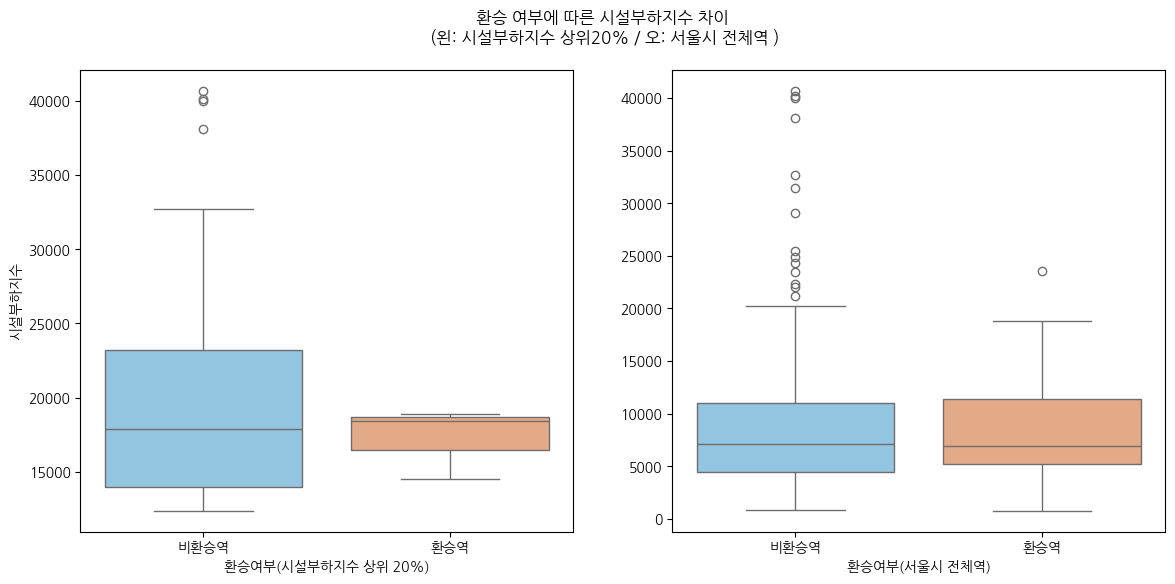

In [213]:
# 환승역 vs. 비환승역
priorities['환승여부'] = ''
priorities.loc[transfer_master['환승노선'].isna(), '환승여부'] = '비환승역'
priorities.loc[~transfer_master['환승노선'].isna(), '환승여부'] = '환승역'

color_dict = {'비환승역': '#86C7ED', '환승역': '#F2A679'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=priorities,
    x='환승여부',
    y='시설부하지수',
    ax=axes[0],
    palette=color_dict,
    hue='환승여부',
    legend=False
)

sns.boxplot(
    data=transfer_master,
    x='환승여부',
    y='시설부하지수',
    ax=axes[1],
    order=['비환승역', '환승역'],
    palette=color_dict,
    hue='환승여부',
    legend=False
)

plt.suptitle("환승 여부에 따른 시설부하지수 차이 \n(왼: 시설부하지수 상위20% / 오: 서울시 전체역 )")
axes[1].set_ylabel("")
axes[0].set_xlabel("환승여부(시설부하지수 상위 20%)")
axes[1].set_xlabel("환승여부(서울시 전체역)")
plt.show()

## 구 노선과 신 노선에 따른 시설부하지수 비교

In [214]:
lines_sep_merged[['ES', 'EV', 'TOTAL_W']] = lines_sep_merged[['ES', 'EV', 'TOTAL_W']].astype('Int64')
lines_sep_merged['시설부하지수'] = (lines_sep_merged['무임승하차'] / lines_sep_merged['TOTAL_W']).round(2)

In [215]:
drop_station = ['뚝섬유원지', '당고개', '신내']
lines_sep_merged = lines_sep_merged[~lines_sep_merged['지하철역'].isin(drop_station)]
lines_sep_merged.loc[lines_sep_merged['지하철역']=='서울역', '지하철역'] = '서울'
# 1. 호선명이 '서울'로 잘못 들어간 곳을 다시 '1호선'으로 수정
lines_sep_merged.loc[lines_sep_merged['호선명'] == '서울', '호선명'] = '1호선'

In [216]:
lines_sep_merged_core=lines_sep_merged[lines_sep_merged['지하철역'].isin(priorities['지하철역'])]
lines_sep_merged_core['지하철역'].unique()
lines_sep_merged_core

,호선명,지하철역,전체승하차,무임승하차,무임승하차비중,노선분류,ES,EV,TOTAL_W,시설부하지수
0,1호선,동대문,718764,249909,34.77,old,1,3,13,19223.77
2,1호선,서울,3483172,445341,12.79,old,5,4,21,21206.71
5,1호선,제기동,1011362,558794,55.25,old,2,3,14,39913.86
6,1호선,종각,2191168,291778,13.32,old,2,4,18,16209.89
7,1호선,종로3가,1481992,564539,38.09,old,4,3,16,35283.69
8,1호선,종로5가,1407939,487010,34.59,old,0,3,12,40584.17
9,1호선,청량리,1317194,561250,42.61,old,6,2,14,40089.29
10,2호선,강남,4541560,301448,6.64,old,0,4,16,18840.5
11,2호선,강변,1724930,234284,13.58,old,2,2,10,23428.4
13,2호선,교대,1890674,328795,17.39,old,4,3,16,20549.69


In [217]:
# 호선명을 문자열로 통일 (int 타입이어도 매핑이 동작하도록)
LINE_COLOR_MAP = {
    '1': '#0052A4', '2': '#00A84D', '3': '#EF7C1C', '4': '#00A5DE',
    '5': '#996CAC', '6': '#CD7C2F', '7': '#747F00', '8': '#E6186C', '9': '#BDB092',
}

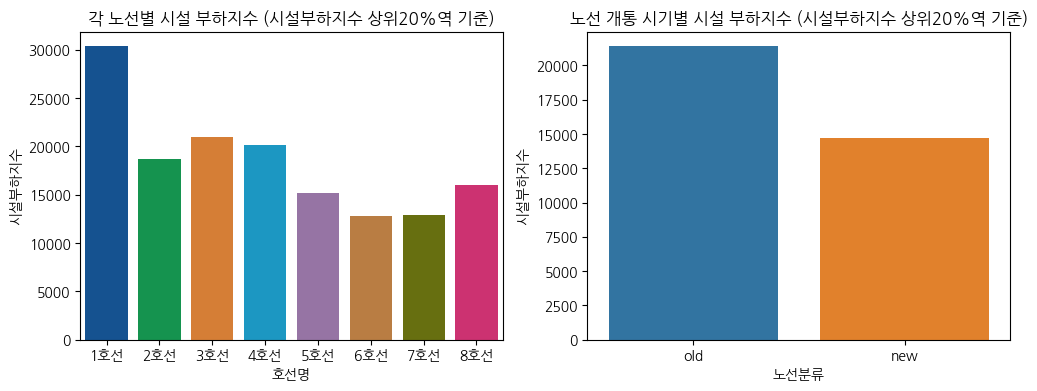

In [218]:
palette_map = {f"{k}호선": v for k, v in LINE_COLOR_MAP.items()}

fig, axes = plt.subplots(1, 2, figsize= (12, 4))

sns.barplot(
    data=lines_sep_merged_core,
    x='호선명',
    y='시설부하지수',
    errorbar=None,
    ax=axes[0],
    palette=palette_map,
    hue='호선명',         
    legend=False
)

sns.barplot(
    data=lines_sep_merged_core,
    x='노선분류',
    y='시설부하지수',
    hue='노선분류',
    errorbar=None,
    ax=axes[1]
)

axes[0].set_title("각 노선별 시설 부하지수 (시설부하지수 상위20%역 기준)")
axes[1].set_title("노선 개통 시기별 시설 부하지수 (시설부하지수 상위20%역 기준)")

plt.show()


In [219]:
ratio_entire = lines_sep_merged['노선분류'].value_counts(normalize=True)
ratio_20percent = lines_sep_merged_core['노선분류'].value_counts(normalize=True)
print(ratio_20percent)
print(ratio_entire)

노선분류
old    0.762712
new    0.237288
Name: proportion, dtype: float64
노선분류
new    0.581315
old    0.418685
Name: proportion, dtype: float64


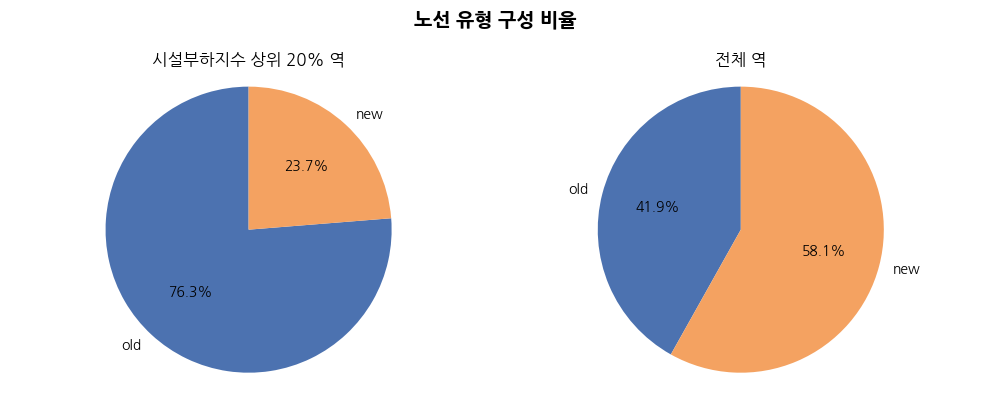

In [220]:
color_map = {
    'old': '#4C72B0',   # 파랑
    'new': '#F4A261'    # 주황
}

order = ['old', 'new']

# 혹시 한쪽 범주가 없더라도 old/new 둘 다 유지
ratio_20percent_plot = ratio_20percent.reindex(order, fill_value=0)
ratio_entire_plot = ratio_entire.reindex(order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 왼쪽
axes[0].pie(
    ratio_20percent_plot,
    labels=order,
    colors=[color_map[k] for k in order],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('시설부하지수 상위 20% 역', fontsize=12)

# 오른쪽
axes[1].pie(
    ratio_entire_plot,
    labels=order,
    colors=[color_map[k] for k in order],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('전체 역', fontsize=12)

for ax in axes:
    ax.axis('equal')

fig.suptitle('노선 유형 구성 비율', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 환승 거리에 따른 시설 효율성 분석

In [221]:
transfer = pd.read_excel("../../data/processed/team/transfer_merged_final.xlsx")

In [222]:
transfer['TOTAL_W'] = transfer['ES'] + transfer['EV']*4
transfer['시설효율성'] = (transfer['환승거리'] / transfer['TOTAL_W']).round(2)
transfer['시설부하지수'] = (transfer['무임승하차'].str.replace(",", "").astype('Int64') / transfer['TOTAL_W']).round(2)
transfer.columns

Index(['호선명', '지하철역', '총승차인원', '무임승차인원', '총하차인원', '무임하차인원', '전체승하차', '무임승하차',
       '무임승하차비중', 'ES', 'EV', 'MW', 'WL', 'TOTAL', '호선', '환승노선', '환승거리',
       '환승소요시간', 'TOTAL_W', '시설효율성', '시설부하지수'],
      dtype='object')

In [223]:
transfer = transfer[['호선명', '지하철역','전체승하차', '무임승하차','무임승하차비중', 'ES', 'EV', 'MW', 'WL', 'TOTAL', '호선', '환승노선', '환승거리', '환승소요시간', 'TOTAL_W', '시설효율성', '시설부하지수']]
transfer

,호선명,지하철역,전체승하차,무임승하차,무임승하차비중,ES,EV,MW,WL,TOTAL,호선,환승노선,환승거리,환승소요시간,TOTAL_W,시설효율성,시설부하지수
0,"3,7,9",고속터미널,5041958,745834,14.79,77,10,4,4,95,7.0,9호선,314.0,04:22,117,2.68,6374.65
1,"1,3,5",종로3가,3088248,901715,29.20,20,7,2,0,29,1.0,5호선,312.0,04:20,48,6.50,18785.73
2,"4,7",노원,2677934,532429,19.88,25,7,0,0,32,4.0,7호선,278.0,03:52,53,5.25,10045.83
3,"2,7",대림,1991465,368397,18.50,19,7,0,1,27,2.0,7호선,276.0,03:50,47,5.87,7838.23
4,"4,9",동작,213077,57987,27.21,21,9,2,0,32,4.0,9호선,245.0,03:24,57,4.30,1017.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,9,신방화,400608,99937,24.95,22,4,0,0,26,NaN,NaN,NaN,NaN,38,NaN,2629.92
248,9,양천향교,582088,98776,16.97,27,4,0,0,31,NaN,NaN,NaN,NaN,43,NaN,2297.12
249,9,염창,1004681,159211,15.85,12,4,0,0,16,NaN,NaN,NaN,NaN,28,NaN,5686.11
250,9,증미,428833,77371,18.04,18,3,0,0,21,NaN,NaN,NaN,NaN,30,NaN,2579.03


[]

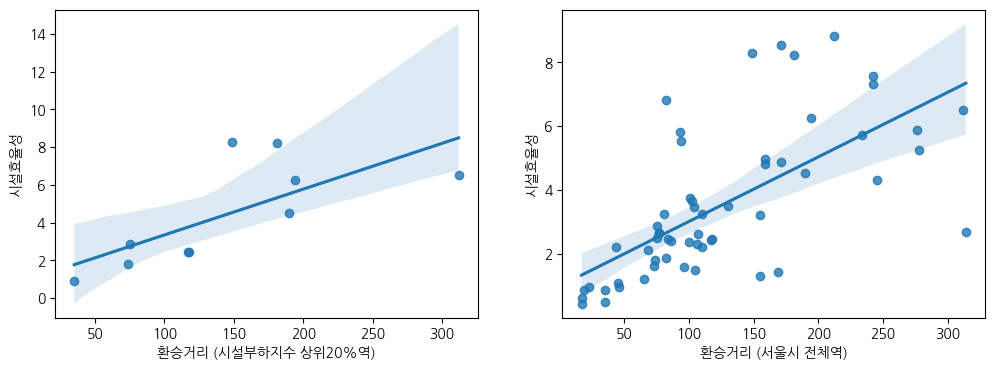

In [224]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.regplot(data=transfer[transfer['지하철역'].isin(common_station)], x='환승거리', y='시설효율성', ax=axes[0])
sns.regplot(data=transfer, x='환승거리', y='시설효율성', ax=axes[1])
axes[0].set_xlabel("환승거리 (시설부하지수 상위20%역)")
axes[1].set_xlabel("환승거리 (서울시 전체역)")
plt.plot()

## 인프라 사각지대의 절대적 공급 부족에 대한 분석

In [225]:
base_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv")
base_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.28
240,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.50
241,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.69
242,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.39


In [226]:
# 총 시설 수 5이하인 역 필터링
total_under_5_df = base_df[base_df['TOTAL'] <= 5].copy()
total_under_5_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94
5,강변,2,888712,119587,836482,115283,1725194,234870,13.61,2,2,4,23487.00
9,도림천,2,37399,8718,39669,9693,77068,18411,23.89,2,0,2,2301.38
12,방배,2,485486,78042,499315,77140,984801,155182,15.76,3,2,5,11084.43
18,선릉,2,1557470,234282,1369726,206084,2927196,440366,15.04,3,2,5,31454.71
20,신답,2,47284,9756,52309,10300,99593,20056,20.14,2,0,2,2507.00
27,양천구청,2,197538,53520,206684,54294,404222,107814,26.67,3,2,5,7701.00
29,용답,2,87730,18244,86887,18091,174617,36335,20.81,2,0,2,4541.88


In [227]:
# (TOTAL <= 5)인 역들 무임승하차비중을 기준으로 내림차순 정리
total_under_5_descending_df = total_under_5_df.sort_values(by='무임승하차비중', ascending=False)
total_under_5_descending_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
95,명일,5,252942,73518,255248,75135,508190,148653,29.25,3,2,5,10618.07
60,홍제,3,530608,146942,503869,144399,1034477,291341,28.16,3,0,3,24278.42
80,개롱,5,190212,53640,196781,55256,386993,108896,28.14,3,2,5,7778.29
50,무악재,3,125533,32954,124422,35259,249955,68213,27.29,3,0,3,5684.42
27,양천구청,2,197538,53520,206684,54294,404222,107814,26.67,3,2,5,7701.00
81,개화산,5,172565,43852,164917,42730,337482,86582,25.66,2,0,2,10822.75
65,미아사거리,4,779304,190582,765423,190213,1544727,380795,24.65,2,2,4,38079.50
59,학여울,3,73982,18231,75530,17950,149512,36181,24.20,3,2,5,2584.36


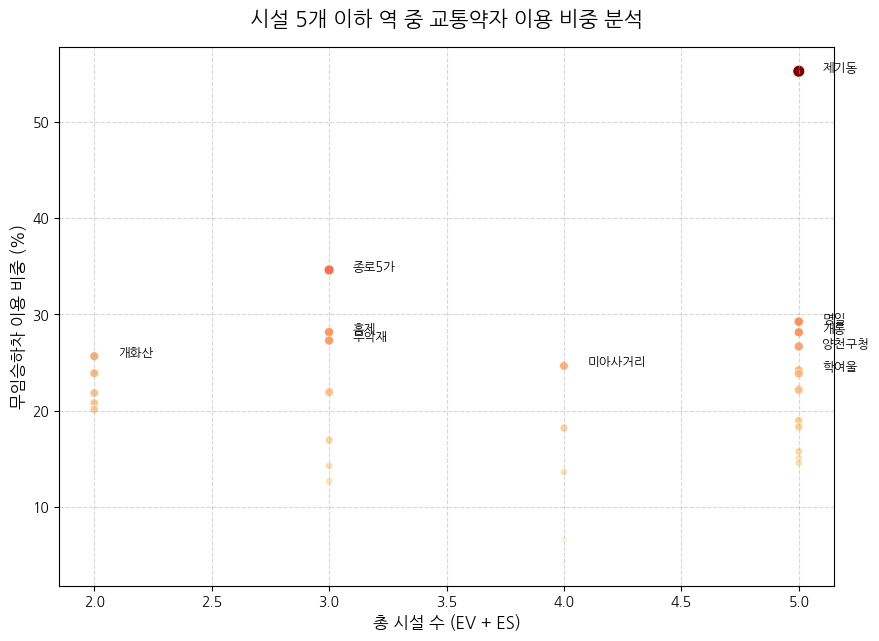

In [228]:
plt.figure(figsize=(10, 7))

# 산점도 그리기 (비중이 높을수록 진하게 표시)
sns.scatterplot(
    data=total_under_5_descending_df,
    x='TOTAL',
    y='무임승하차비중',
    size='무임승하차비중',  # 비중에 따라 점 크기 조절
    hue='무임승하차비중',  # 비중에 따라 색상 조절
    palette='OrRd',
    legend=False
)

# 텍스트 라벨 추가 (상위 몇 개 역만 이름 표시해서 가독성 확보)
# 비중이 높은 상위 10개 역만 이름을 표시합니다.
top_labeled = total_under_5_descending_df.head(10)
for i, row in top_labeled.iterrows():
    plt.text(row['TOTAL']+0.1, row['무임승하차비중'], row['지하철역'], fontsize=9)

plt.title('시설 5개 이하 역 중 교통약자 이용 비중 분석', fontsize=15, pad=15)
plt.xlabel('총 시설 수 (EV + ES)', fontsize=12)
plt.ylabel('무임승하차 이용 비중 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [229]:
# 시설 1개당 감당해야 하는 체감 비중 계산, 시설이 적을수록 이 수치가 커지므로 사각지대를 찾는 데 유리함
total_under_5_descending_df['시설당_체감비중'] = (
    total_under_5_descending_df['무임승하차비중'] / total_under_5_descending_df['TOTAL']
)

# 절대적인 비중이 높은 역 (예: 제기동)
high_ratio_stations = total_under_5_descending_df.sort_values(by='무임승하차비중', ascending=False).head(3)

# 시설 대비 비중이 너무 높은 사각지대 역
dead_zone_stations = total_under_5_descending_df.sort_values(by='시설당_체감비중', ascending=False).head(3)

# 결과 출력
print("--- [분석 결과 도출] ---")
print(f"1. 이용 비중 최상위(부하 집중): {', '.join(high_ratio_stations['지하철역'].values)}")
print(f"2. 시설 대비 수요 최상위(사각지대): {', '.join(dead_zone_stations['지하철역'].values)}")
print("-" * 30)

# 간단한 요약 코멘트 출력
for _, row in dead_zone_stations.iterrows():
    print(f"'{row['지하철역']}'의 시설은 단 {row['TOTAL']}개뿐인데, 이용 비중은 {row['무임승하차비중']:.1f}%에 달해 집중 관리가 시급함")

--- [분석 결과 도출] ---
1. 이용 비중 최상위(부하 집중): 제기동, 종로5가, 명일
2. 시설 대비 수요 최상위(사각지대): 개화산, 도림천, 종로5가
------------------------------
'개화산'의 시설은 단 2개뿐인데, 이용 비중은 25.7%에 달해 집중 관리가 시급함
'도림천'의 시설은 단 2개뿐인데, 이용 비중은 23.9%에 달해 집중 관리가 시급함
'종로5가'의 시설은 단 3개뿐인데, 이용 비중은 34.6%에 달해 집중 관리가 시급함


## 시설 공급 대비 이용 부하 분석

In [231]:
base_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv")
base_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.28
240,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.50
241,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.69
242,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.39


In [232]:
base_df['no_weight_시설부하지수'] = (base_df['무임승하차'] / base_df['TOTAL']).round(2)

In [233]:
base_no_weight_descending_df = base_df.sort_values(by='no_weight_시설부하지수', ascending=False).copy()

index = int(len(base_no_weight_descending_df) * 0.2)

top_20_no_weight_df = base_no_weight_descending_df.iloc[:index].copy()

print(f"전체 역 개수: {len(base_no_weight_descending_df)}")
print(f"상위 20% 역 개수: {len(top_20_no_weight_df)}")
top_20_no_weight_df.head()

전체 역 개수: 244
상위 20% 역 개수: 48


,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,no_weight_시설부하지수
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,162773.00
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,111943.20
60,홍제,3,530608,146942,503869,144399,1034477,291341,28.16,3,0,3,24278.42,97113.67
65,미아사거리,4,779304,190582,765423,190213,1544727,380795,24.65,2,2,4,38079.50,95198.75
18,선릉,2,1557470,234282,1369726,206084,2927196,440366,15.04,3,2,5,31454.71,88073.20


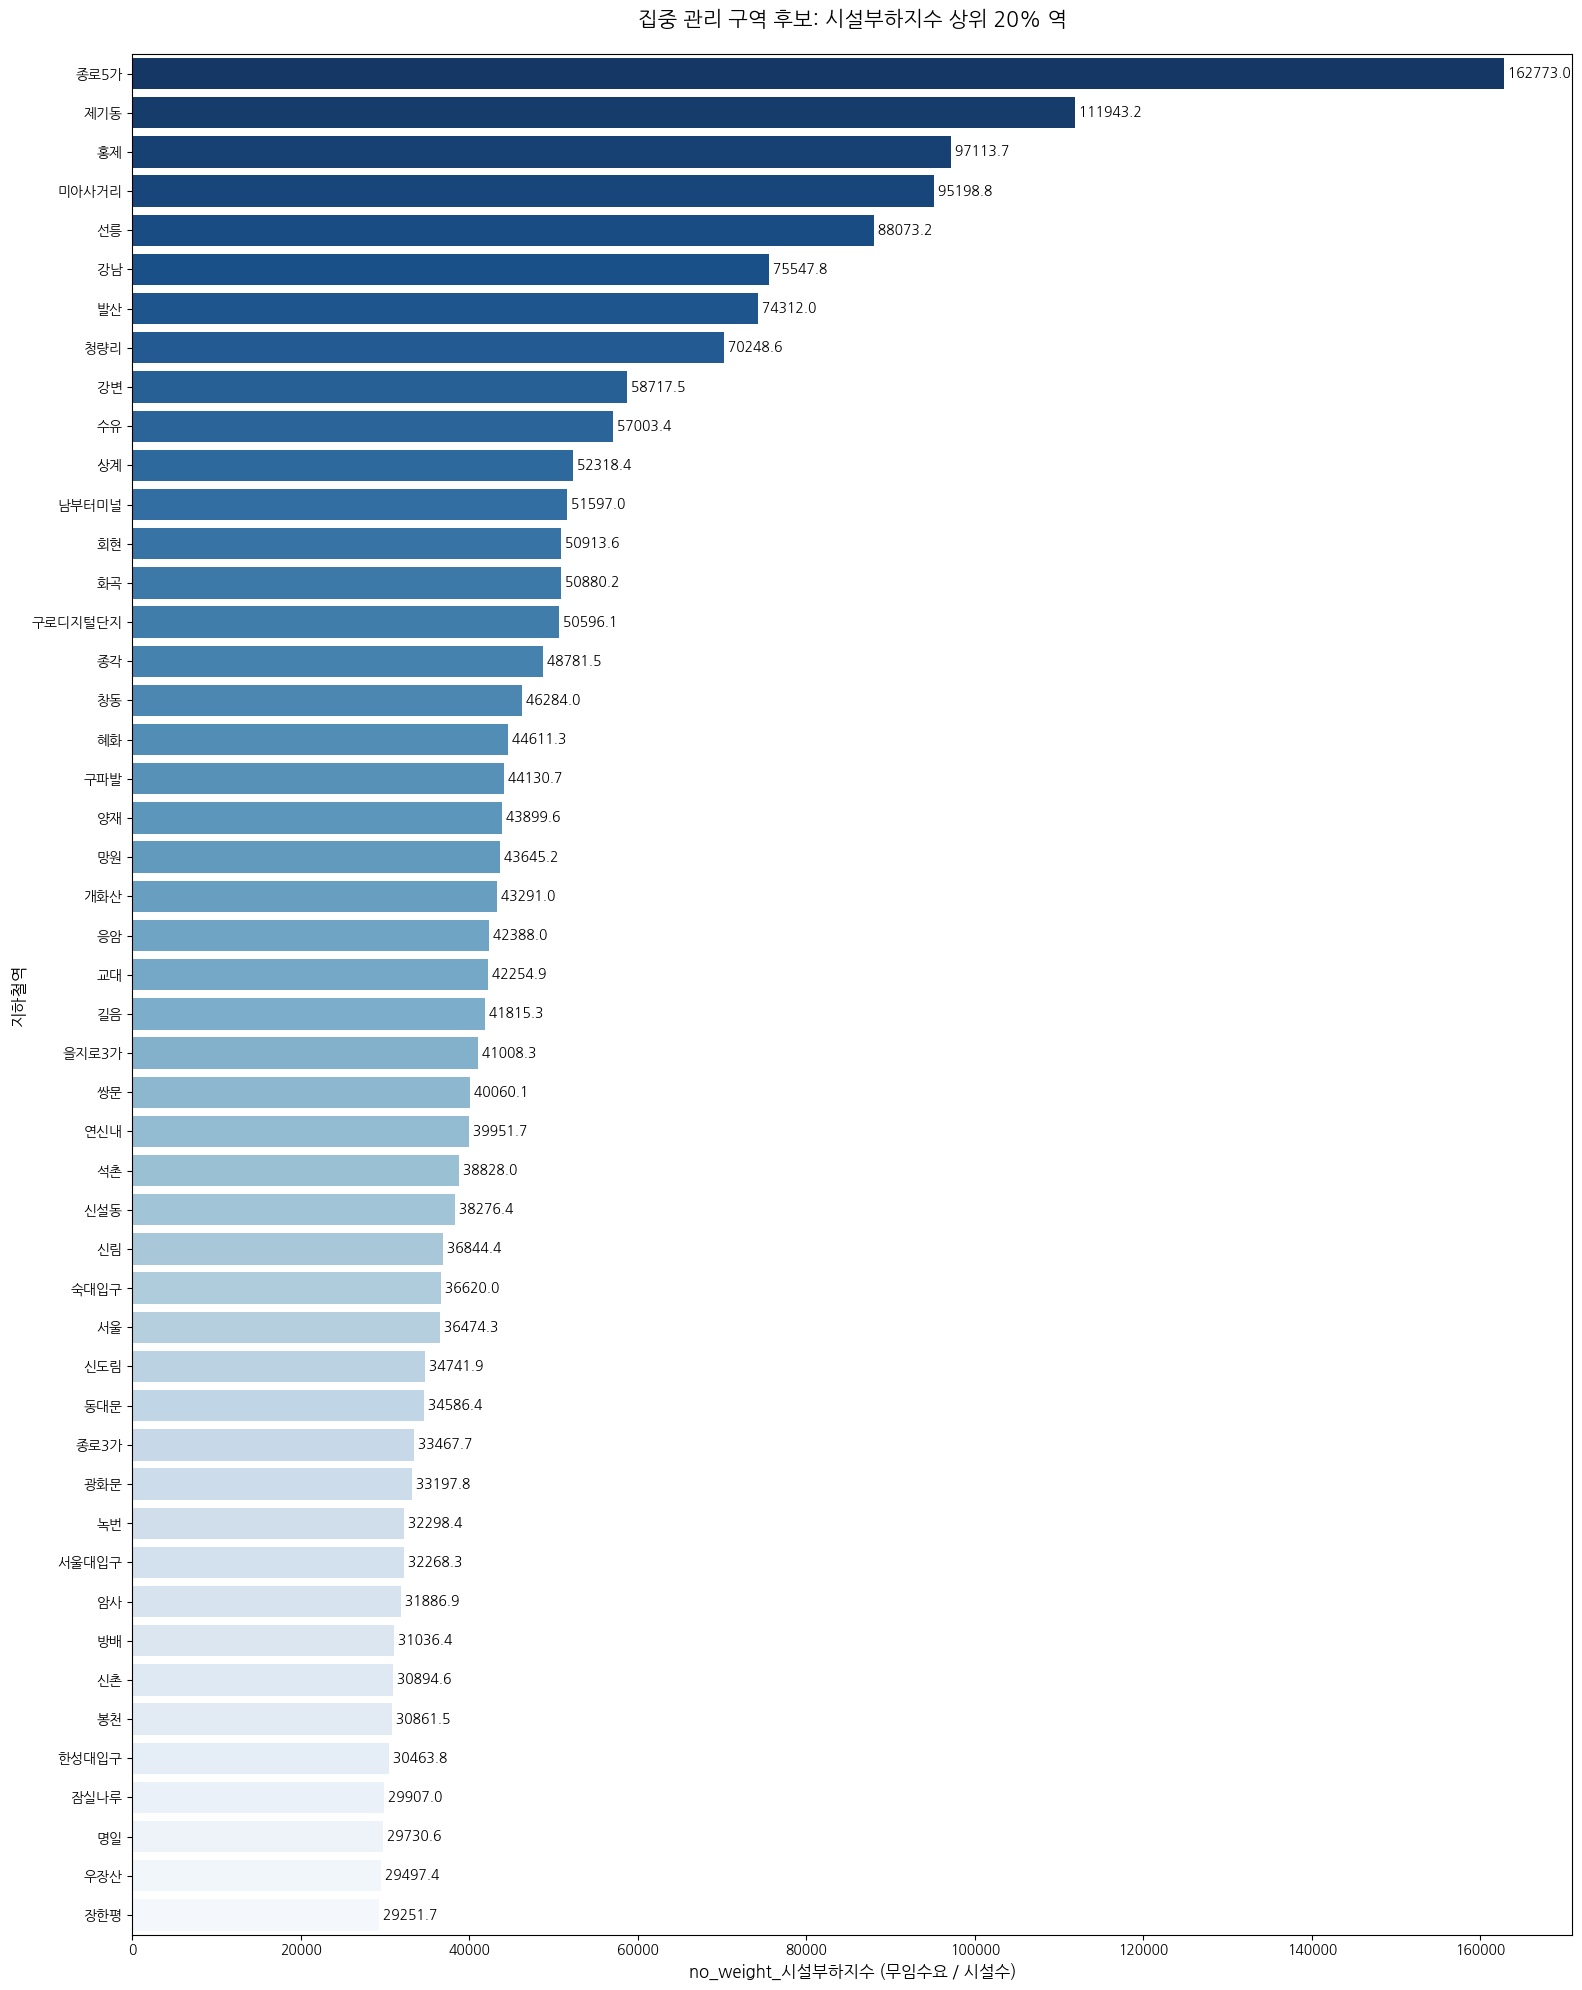

In [234]:
# 가중치 적용 X , 상위 20%역 시각화
plt.figure(figsize=(16, 20))

sns.barplot(
    data=top_20_no_weight_df,
    x='no_weight_시설부하지수',
    y='지하철역',
    hue='지하철역',
    palette='Blues_r',
    legend=False
)

plt.title('집중 관리 구역 후보: 시설부하지수 상위 20% 역', fontsize=15, pad=20)
plt.xlabel('no_weight_시설부하지수 (무임수요 / 시설수)', fontsize=12)
plt.ylabel('지하철역', fontsize=12)

for i, val in enumerate(top_20_no_weight_df['no_weight_시설부하지수']):
    plt.text(val, i, f' {val:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [235]:
base_descending_df = base_df.sort_values(by='시설부하지수', ascending=False).copy()

index = int(len(base_descending_df) * 0.2)

top_20_df = base_descending_df.iloc[:index].copy()

print(f"전체 역 개수: {len(base_descending_df)}")
print(f"상위 20% 역 개수: {len(top_20_df)}")
top_20_df.head()

전체 역 개수: 244
상위 20% 역 개수: 48


,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,no_weight_시설부하지수
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,162773.00
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07,70248.62
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,111943.20
65,미아사거리,4,779304,190582,765423,190213,1544727,380795,24.65,2,2,4,38079.50,95198.75
67,상계,4,567980,132469,528993,129123,1096973,261592,23.85,1,4,5,32699.00,52318.40


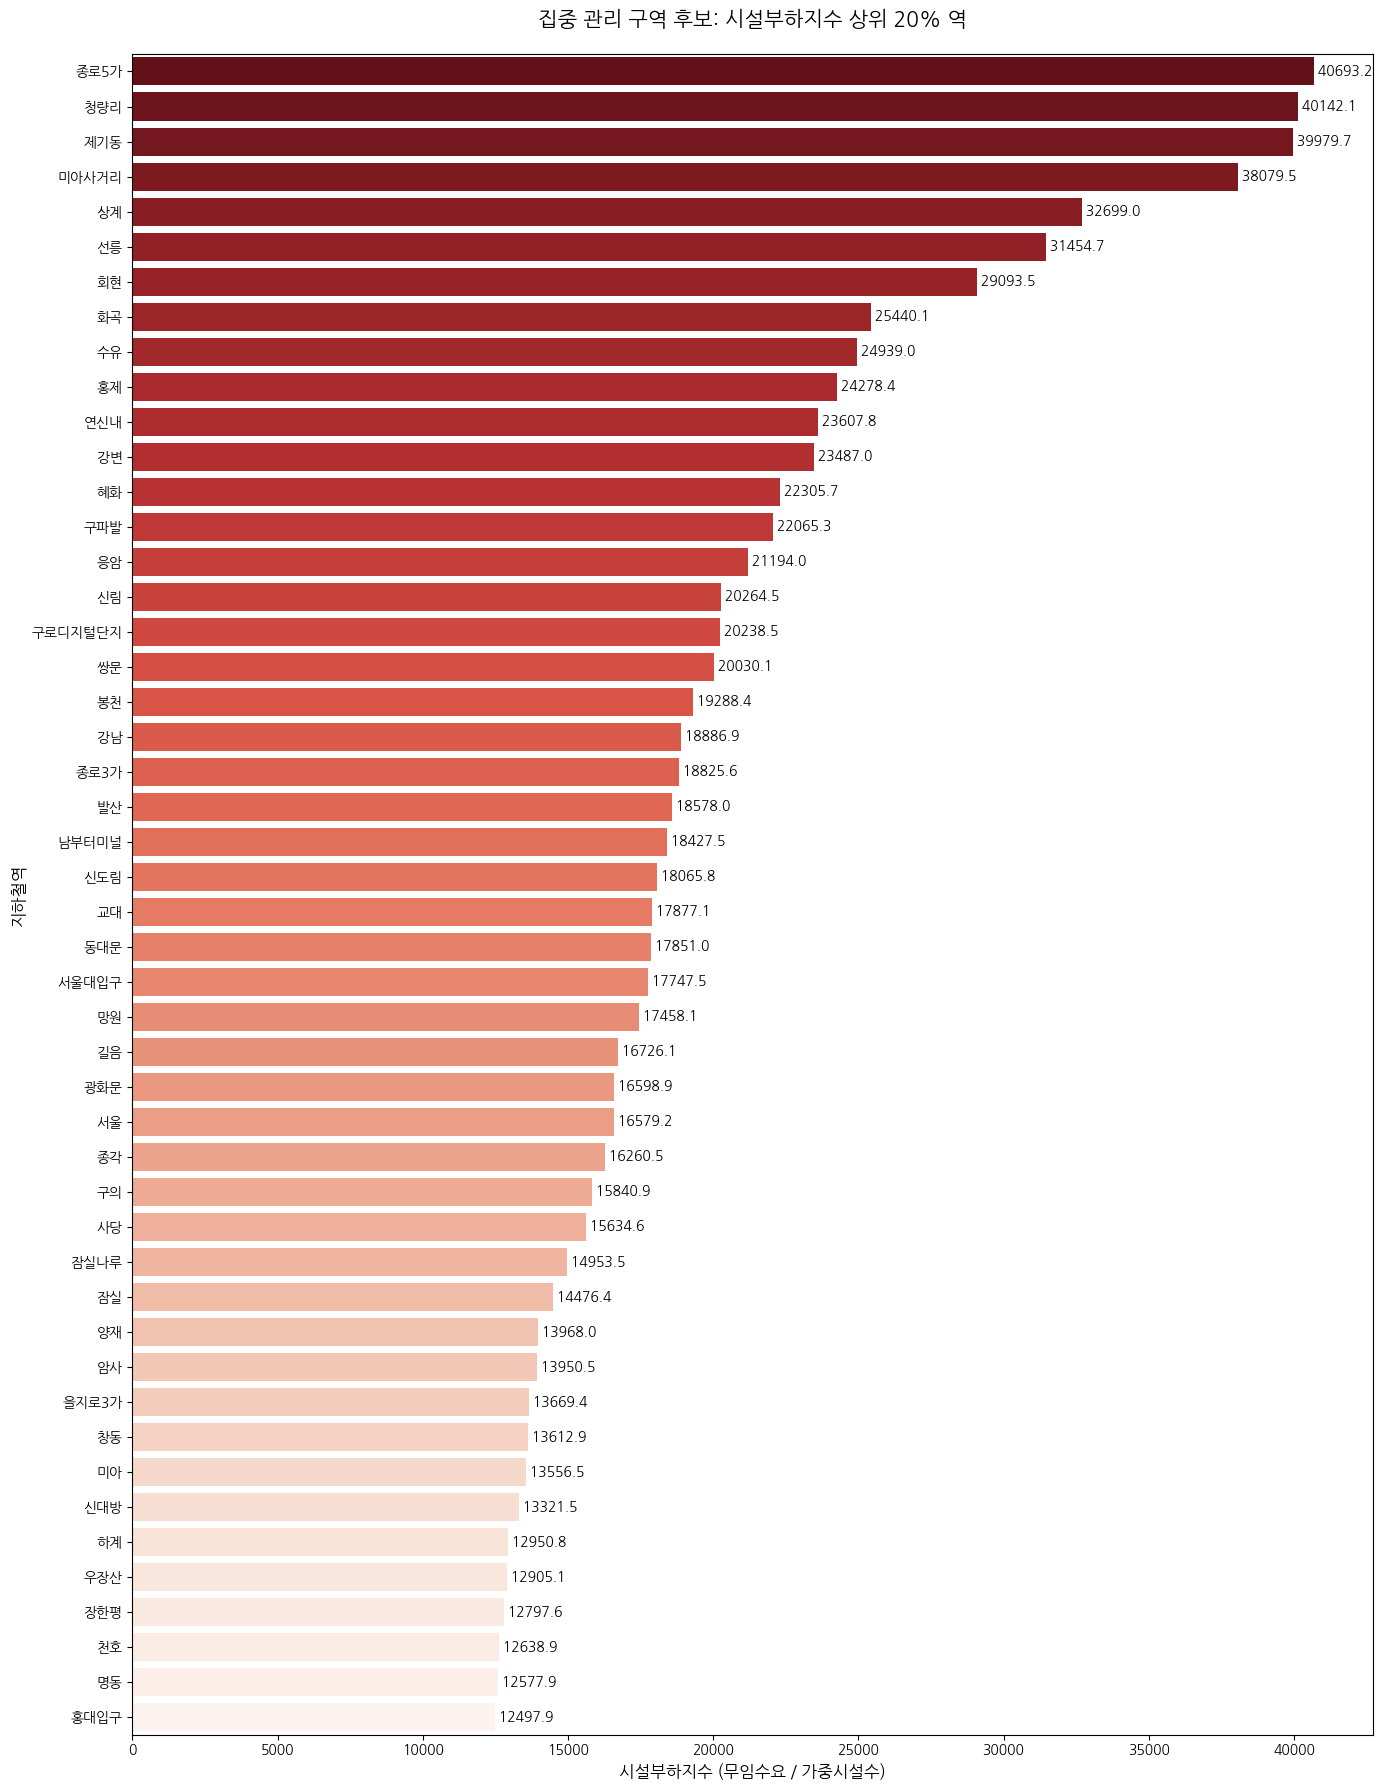

In [236]:
# 가중치 적용 O , 상위 20%역 시각화
plt.figure(figsize=(14, 18))

sns.barplot(
    data=top_20_df,
    x='시설부하지수',
    y='지하철역',
    hue='지하철역',
    palette='Reds_r',
    legend=False
)

plt.title('집중 관리 구역 후보: 시설부하지수 상위 20% 역', fontsize=15, pad=20)
plt.xlabel('시설부하지수 (무임수요 / 가중시설수)', fontsize=12)
plt.ylabel('지하철역', fontsize=12)

for i, val in enumerate(top_20_df['시설부하지수']):
    plt.text(val, i, f' {val:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

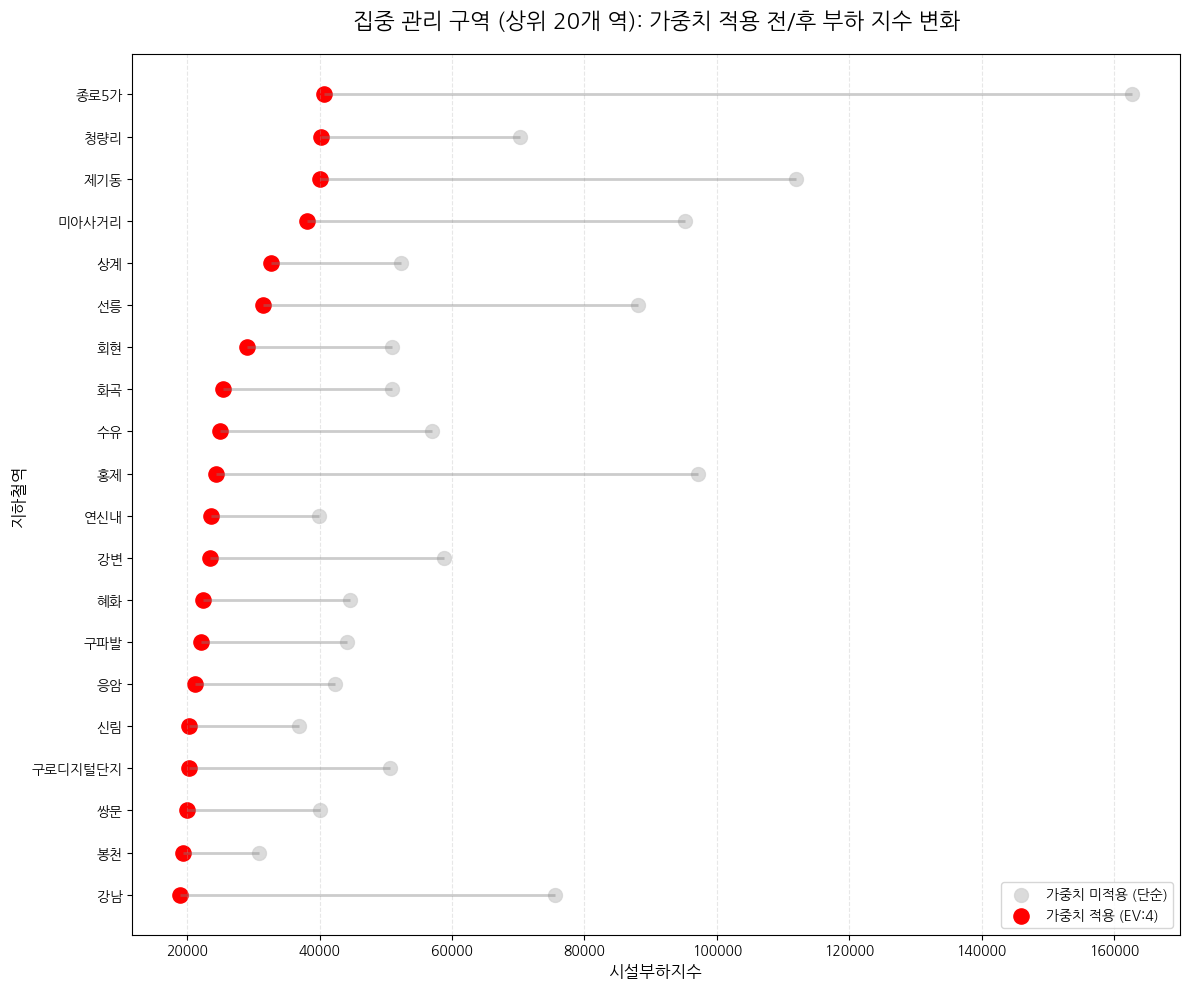

In [238]:
# 상위 20개 추출 후 순서를 뒤집어서 위에서부터 큰 값이 오게 하기
df_plot = top_20_df.head(20).iloc[::-1].copy()

# 상위 20개 역 가중치 전/후 시설부하지수 변화 시각화
plt.figure(figsize=(12, 10))

# 배경에 회색 점선
plt.hlines(y=df_plot['지하철역'], xmin=df_plot['no_weight_시설부하지수'], 
           xmax=df_plot['시설부하지수'], color='grey', alpha=0.4, linewidth=2)

# 가중치 미적용 지수 (회색)
plt.scatter(df_plot['no_weight_시설부하지수'], df_plot['지하철역'], 
            color='lightgrey', alpha=0.8, s=100, label='가중치 미적용 (단순)')

# 가중치 적용 지수 (빨간색)
plt.scatter(df_plot['시설부하지수'], df_plot['지하철역'], 
            color='red', alpha=1, s=120, label='가중치 적용 (EV:4)')

plt.title('집중 관리 구역 (상위 20개 역): 가중치 적용 전/후 부하 지수 변화', fontsize=16, pad=20)
plt.xlabel('시설부하지수', fontsize=12)
plt.ylabel('지하철역', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 1~8호선 심도 데이터와 9호선 심도 데이터 병합 및 전처리 분석

In [239]:
# 1~8호선 심도 데이터, 9호선 심도 데이터, 통합된 기본 데이터 가져오기
depth_1to8_df = pd.read_csv("../../data/raw/서울교통공사_1~8호선_역사심도정보_20250814.csv", encoding='cp949')
depth_9_df = pd.read_csv("../../data/raw/서울교통공사_9호선 2_3단계 역사 심도 정보_20250813.csv", encoding='cp949')
base_df = pd.read_excel("../../data/processed/team/subway_merged_base.xlsx")

In [240]:
# 1~8호선 필요 컬럼 추출 후 컬럼명 변환
depth_1to8_cleaned_df = depth_1to8_df[['역명', '층수', '정거장깊이']].copy()
depth_1to8_cleaned_df.rename(columns={'역명' : '지하철역', '정거장깊이' : '심도'}, inplace=True)

# 9호선 필요 컬럼 추출 후 컬럼명 변환
depth_9_cleaned_df = depth_9_df[['정거장명', '정거장층수', '승강장기준 정거장 깊이(m)']].copy()
depth_9_cleaned_df.rename(columns={'정거장명':'지하철역', '정거장층수':'층수', '승강장기준 정거장 깊이(m)':'심도'}, inplace=True)

In [241]:
# 1~8호선 필요 컬럼 추출 데이터와 9호선 필요 컬럼 추출 데이터를 행 방향으로 병합
depth_all_df = pd.concat([depth_1to8_cleaned_df, depth_9_cleaned_df], axis=0, ignore_index=True)

In [242]:
# 서울시가 아닌 역들 제외하기
non_seoul = [
    # 5호선 (하남)
    '미사', '하남검단산', '하남시청(덕풍?신장)', '하남풍산',
    # 7호선 (경기/인천)
    '광명사거리', '굴포천', '까치울', '부천시청', '부평구청',
    '삼산체육관', '상동', '신중동', '춘의', '철산',
    # 8호선 (성남)
    '남위례', '남한산성입구(성남법원.검찰청)', '단대오거리',
    '모란', '복정', '산성', '수진', '신흥',
]

depth_all_cleaned_df = depth_all_df[~depth_all_df['지하철역'].isin(non_seoul)].copy()
depth_all_cleaned_df

,지하철역,층수,심도
0,서울,B2,11.850
1,시청,B2,10.050
2,종각,B2,11.430
3,종로3가,B2,11.240
4,종로5가,B2,11.390
...,...,...,...
284,송파나루,B2,17.381
285,한성백제,B2,17.970
286,올림픽공원,B3,22.370
287,둔촌오륜,B2,21.410


In [243]:
# 맨 뒤에 역이라고 되어 있는 거는 역만 삭제
depth_all_cleaned_df['지하철역'] = depth_all_cleaned_df['지하철역'].str.replace('역$', '', regex=True)

# 앞 뒤 공백 제거
depth_all_cleaned_df['지하철역'] = depth_all_cleaned_df['지하철역'].str.strip()

In [244]:
# 지하철역별로 층수와 심도 집계 -> 지하철역이 겹칠 땐 더 깊은 역으로 집계
depth_final_df = depth_all_cleaned_df.groupby('지하철역').agg({
    '층수' : 'max',
    '심도' : 'max'
}).reset_index()

depth_final_df

,지하철역,층수,심도
0,DMC,B2,11.57
1,가락시장,B4,23.33
2,가산디지털단지,B4,26.67
3,강남,B2,11.96
4,강남구청,B3,21.72
...,...,...,...
237,홍제,B3,15.82
238,화곡,B3,18.90
239,화랑대,B2,15.57
240,회현,B4,22.09


In [245]:
# 기본 데이터에서 매칭이 안된 역
missing_depth = set(base_df['지하철역']) - set(depth_final_df['지하철역'])

# 심도 데이터에만 있는 역
extra_depth = set(depth_final_df['지하철역']) - set(base_df['지하철역'])

print(f"매칭 안 된 역({len(missing_depth)}개):", missing_depth)
print('='*50)
print(f"심도 데이터에만 있는 후보군:", extra_depth)

매칭 안 된 역(29개): {'신반포', '신목동', '구로디지털단지', '증미', '구반포', '신방화', '숭실대입구', '신논현', '국회의사당', '미아사거리', '신대방삼거리', '마곡나루', '염창', '사평', '양천향교', '흑석', '노들', '둔촌동', '노량진', '공항시장', '불암산', '가양', '샛강', '개화', '애오개', '등촌', '선유도', '자양', '디지털미디어시티'}
심도 데이터에만 있는 후보군: {'중앙보훈병원', '둔촌오륜', '당고개', '삼성중앙', '언주', '송파나루', '남한산성입구', '선정릉', '애오게', '둔촌', '광명', '총신대입구', '지축', '을지3가', '봉은사', '숭실대', '구로디지털', '을지4가', 'DMC', '미아삼거리', '삼전', '동대문운동장', '한성백제', '하남시청', '석촌고분', '뚝섬유원지', '신내'}


In [246]:
# 눈에 띄는 차이를 지닌 이름들 매핑
name_map = {
    '애오게': '애오개',        # 오타 수정
    '둔촌': '둔촌동',
    '뚝섬유원지': '자양',       # 최근 변경된 역명 반영
    '당고개': '불암산',         # 최근 변경된 역명 반영
    '숭실대': '숭실대입구',
    '미아삼거리': '미아사거리',
    '구로디지털': '구로디지털단지',
    'DMC': '디지털미디어시티',
    '총신대입구': '이수'
}

depth_final_df['지하철역'] = depth_final_df['지하철역'].replace(name_map)

In [247]:
df_final = pd.merge(base_df, depth_final_df, on='지하철역', how='left')
df_final.head()

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,층수,심도
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,B2,9.32
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50,B2,11.43
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,B2,11.39
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07,B2,5.34
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94,B2,11.96


In [248]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   지하철역     245 non-null    object 
 1   호선명      245 non-null    object 
 2   총승차인원    245 non-null    int64  
 3   무임승차인원   245 non-null    int64  
 4   총하차인원    245 non-null    int64  
 5   무임하차인원   245 non-null    int64  
 6   전체승하차    245 non-null    int64  
 7   무임승하차    245 non-null    int64  
 8   무임승하차비중  245 non-null    float64
 9   EV       245 non-null    int64  
 10  ES       245 non-null    int64  
 11  TOTAL    245 non-null    int64  
 12  시설부하지수   245 non-null    float64
 13  층수       224 non-null    object 
 14  심도       224 non-null    float64
dtypes: float64(3), int64(9), object(3)
memory usage: 28.8+ KB


In [249]:
df_final['지하철역'].duplicated().sum()

np.int64(1)

In [250]:
df_final[df_final['지하철역'].duplicated(keep=False)]

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,층수,심도
243,이수,"4,7",1043396,244929,1074046,248082,2117442,493011,23.28,7,27,34,8963.84,B4,22.62
244,이수,"4,7",1043396,244929,1074046,248082,2117442,493011,23.28,7,27,34,8963.84,B2,13.55


In [251]:
# 이수역 데이터 합치는 코드
df_others = df_final[df_final['지하철역'] != '이수'].copy()
df_isu = df_final[df_final['지하철역'] == '이수'].copy()

df_isu_fixed = df_isu.groupby('지하철역').agg({
    '호선명': lambda x: ','.join(x.unique()),
    '총승차인원': 'first',
    '무임승차인원': 'first',
    '총하차인원': 'first',
    '무임하차인원': 'first',
    '전체승하차': 'first',
    '무임승하차': 'first',
    '무임승하차비중': 'first',
    'ES': 'first',
    'EV': 'first',
    'TOTAL': 'first',
    '층수': 'max',
    '심도': 'max'
}).reset_index()

df_final_fixed = pd.concat([df_others, df_isu_fixed], ignore_index=True)

# 이수역 시설부하지수 채우기
df_final_fixed.loc[df_final_fixed['지하철역'] == '이수', '시설부하지수'] = (
    df_final_fixed['무임승하차'] / (df_final_fixed['EV'] * 4 + df_final_fixed['ES'] * 1)
)
df_final_fixed['시설부하지수'] = df_final_fixed['시설부하지수'].round(2)
df_final_fixed

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,층수,심도
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,B2,9.32
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50,B2,11.43
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,B2,11.39
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07,B2,5.34
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94,B2,11.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.28,B4,26.59
240,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.50,B5,30.94
241,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.69,B4,24.05
242,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.39,B4,24.29


In [252]:
# 층수와 심도의 결측값과 개수 확인
missing_rows = df_final_fixed[df_final_fixed['층수'].isna() | df_final_fixed['심도'].isna()]
missing_stations = missing_rows['지하철역'].unique()

print(f"총 {len(missing_stations)}개의 역에 결측치가 있습니다.")
print("-" * 30)
print(missing_stations)

총 21개의 역에 결측치가 있습니다.
------------------------------
['신대방삼거리' '가양' '개화' '공항시장' '구반포' '국회의사당' '노들' '노량진' '등촌' '마곡나루' '사평' '샛강'
 '선유도' '신논현' '신목동' '신반포' '신방화' '양천향교' '염창' '증미' '흑석']


In [253]:
# AI를 활용해 결측값에 대한 정보 채움
manual_data = {
    '개화': {'층수': '1F', '심도': -2.5},
    '공항시장': {'층수': 'B3', '심도': 18.5},
    '신방화': {'층수': 'B3', '심도': 19.8},
    '마곡나루': {'층수': 'B3', '심도': 18.0},
    '양천향교': {'층수': 'B3', '심도': 20.2},
    '가양': {'층수': 'B3', '심도': 20.1},
    '증미': {'층수': 'B3', '심도': 19.5},
    '등촌': {'층수': 'B3', '심도': 18.2},
    '염창': {'층수': 'B4', '심도': 25.4},
    '선유도': {'층수': 'B3', '심도': 19.0},
    '노들': {'층수': 'B3', '심도': 18.8},
    '흑석': {'층수': 'B4', '심도': 26.5},
    '구반포': {'층수': 'B3', '심도': 19.2},
    '신반포': {'층수': 'B3', '심도': 18.5},
    '사평': {'층수': 'B3', '심도': 18.7},
    '신논현': {'층수': 'B4', '심도': 25.8},
    '국회의사당': {'층수': 'B3', '심도': 18.3},
    '샛강': {'층수': 'B3', '심도': 19.4},
    '신목동': {'층수': 'B3', '심도': 19.1},
    '노량진': {'층수': 'B4', '심도': 26.2},
    '신대방삼거리': {'층수': 'B3', '심도': 17.5}
}

# 딕셔너리를 이용해 결측치 업데이트
for station, vals in manual_data.items():
    df_final_fixed.loc[df_final_fixed['지하철역'] == station, ['층수', '심도']] = vals['층수'], vals['심도']

print("남은 결측치 개수:")
print(df_final_fixed[['층수', '심도']].isnull().sum())

남은 결측치 개수:
층수    0
심도    0
dtype: int64


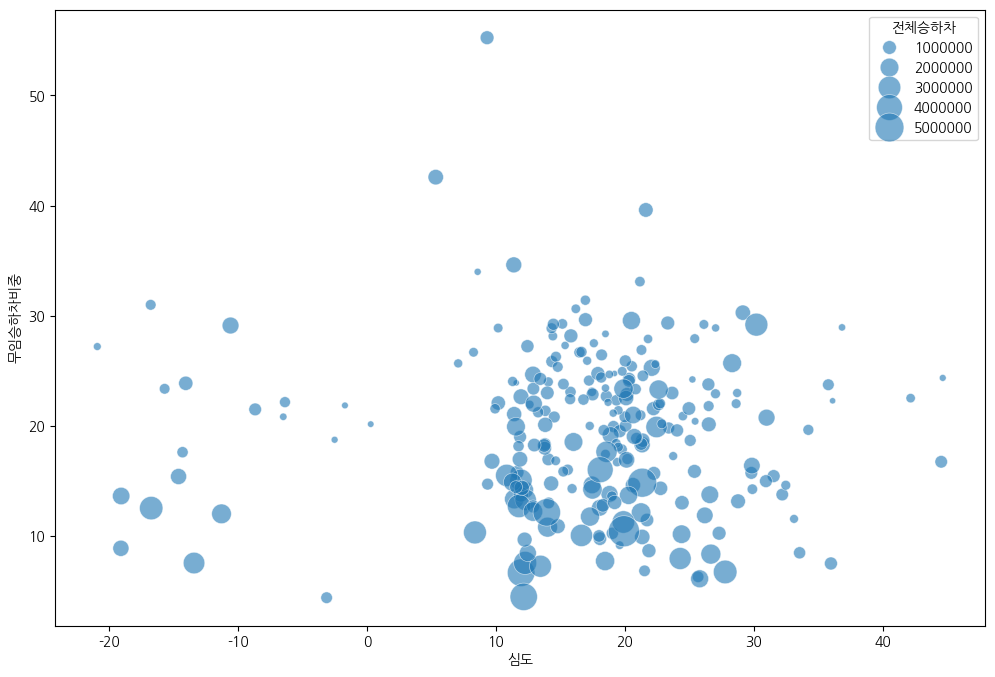

In [254]:
# 심도와 무임승하차비중 관계
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data = df_final_fixed,
    x = '심도',
    y = '무임승하차비중',
    size = '전체승하차',
    alpha = 0.6,
    sizes = (20, 500)
)

plt.show()

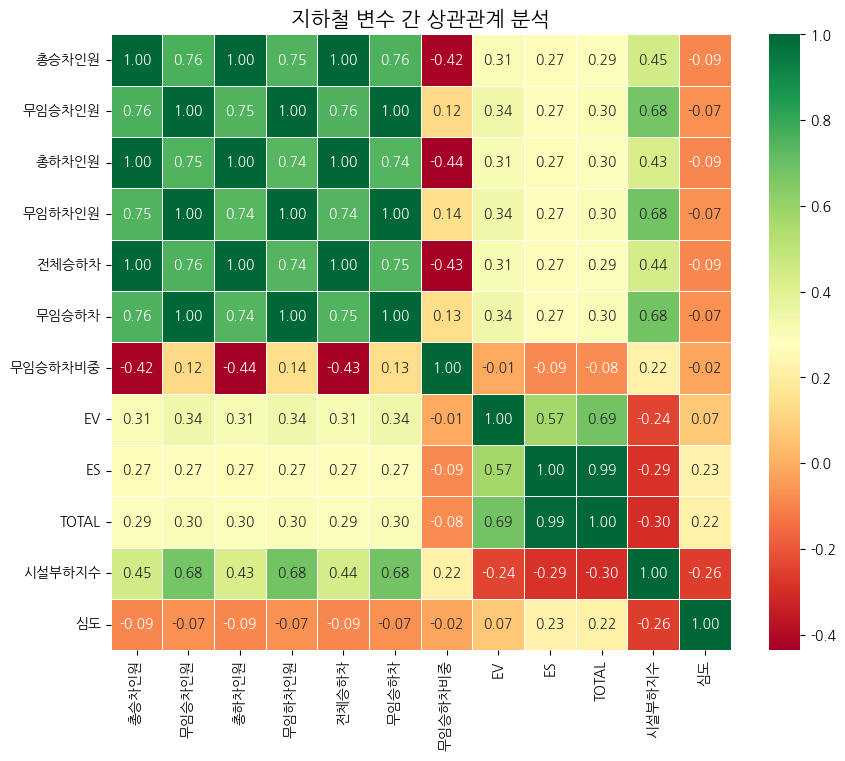

In [255]:
# 숫자형 컬럼만 추출해서 상관계수 히트맵으로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(df_final_fixed.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('지하철 변수 간 상관관계 분석', fontsize=15)
plt.show()

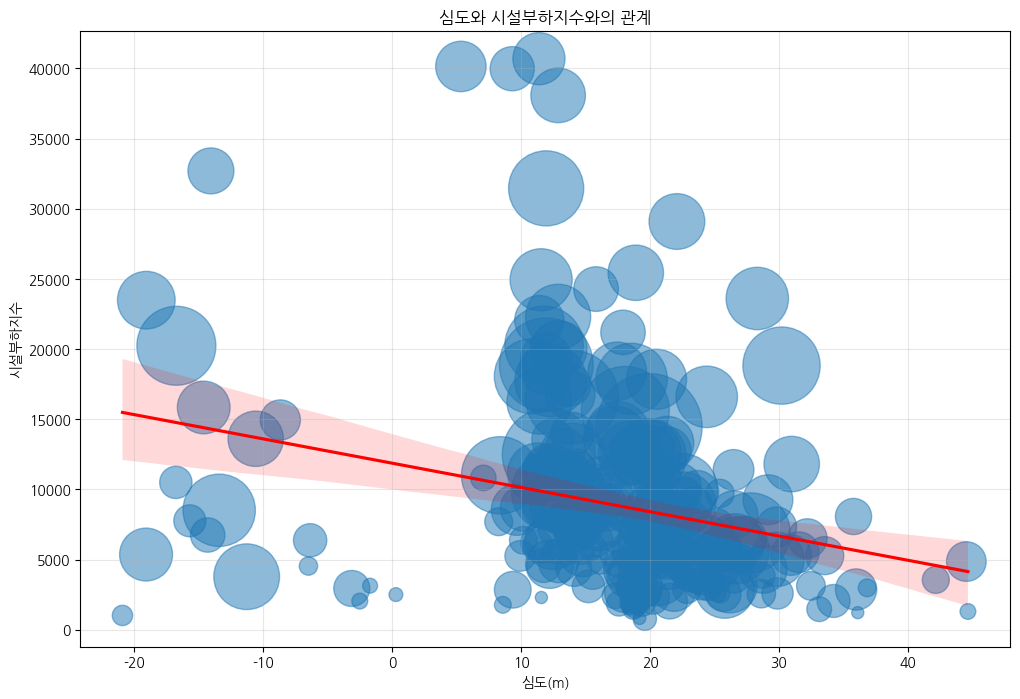

In [256]:
# 심도와 시설부하지수의 관계 시각화
plt.figure(figsize=(12, 8))
sns.regplot(
    data=df_final_fixed,
    x='심도',
    y='시설부하지수',
    scatter_kws={'alpha':0.5, 's':df_final_fixed['전체승하차']/1000}, # 이용객수에 따른 버블 크기
    line_kws={'color':'red'}
)

plt.title('심도와 시설부하지수와의 관계')
plt.xlabel('심도(m)')
plt.ylabel('시설부하지수')
plt.grid(True, alpha=0.3)
plt.show()

In [258]:
high_load_targets = df_final_fixed.nlargest(5, '시설부하지수')

display(high_load_targets[['지하철역', '호선명', '심도', '무임승하차', 'EV', 'ES', '시설부하지수']])

,지하철역,호선명,심도,무임승하차,EV,ES,시설부하지수
2,종로5가,1,11.39,488319,3,0,40693.25
3,청량리,1,5.34,561989,2,6,40142.07
0,제기동,1,9.32,559716,3,2,39979.71
65,미아사거리,4,12.88,380795,2,2,38079.50
67,상계,4,-14.04,261592,1,4,32699.00


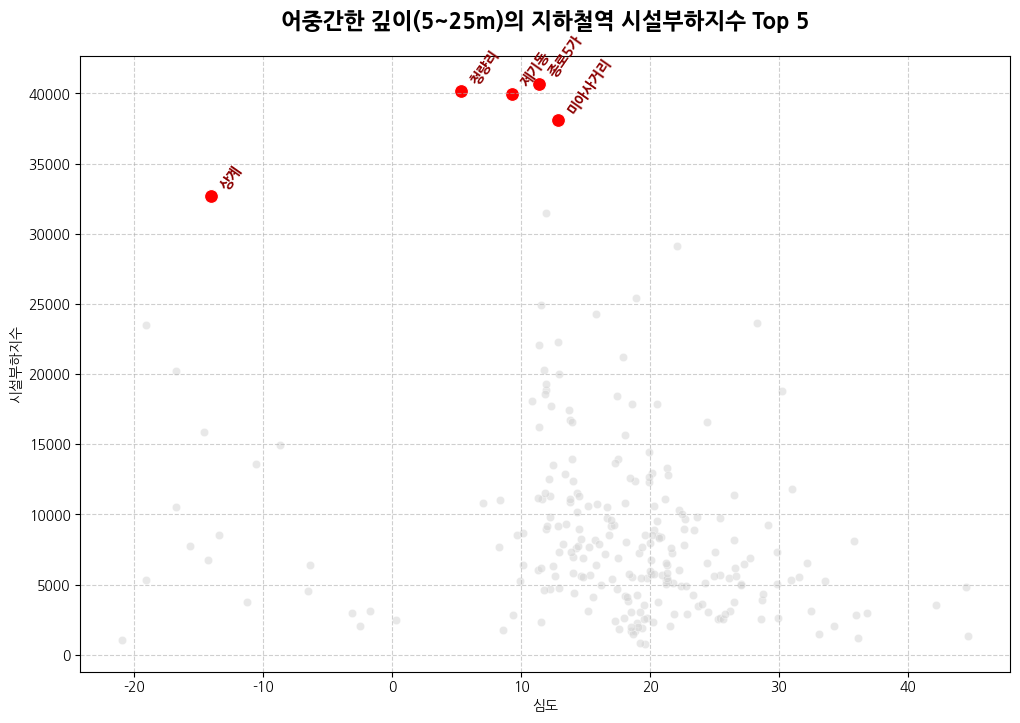

In [259]:
# 어중간한 깊이의 지하철역 시설부하지수 Top 5 보여주는 시각화
plt.figure(figsize=(12, 8))

# 전체 데이터 산점도 (연한 회색으로 배경 처리)
sns.scatterplot(data=df_final_fixed, x='심도', y='시설부하지수', color='lightgray', alpha=0.5)

# 강조하고 싶은 5개 역만 빨간색으로 다시 그리기
sns.scatterplot(data=high_load_targets, x='심도', y='시설부하지수', color='red', s=100)

# 5개 역에 이름 달기
for i in range(len(high_load_targets)):
    plt.annotate(
        high_load_targets.iloc[i]['지하철역'],               # 표시할 텍스트
        (high_load_targets.iloc[i]['심도'], high_load_targets.iloc[i]['시설부하지수']), # 좌표
        textcoords="offset points",                         # 위치 기준
        xytext=(5, 5),                                      # 점으로부터의 거리 (x, y)
        ha='left',                                          # 수평 정렬
        fontsize=10,
        fontweight='bold',
        color='darkred',
        rotation=55
    )

plt.title('어중간한 깊이(5~25m)의 지하철역 시설부하지수 Top 5', fontsize=16, pad=20, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

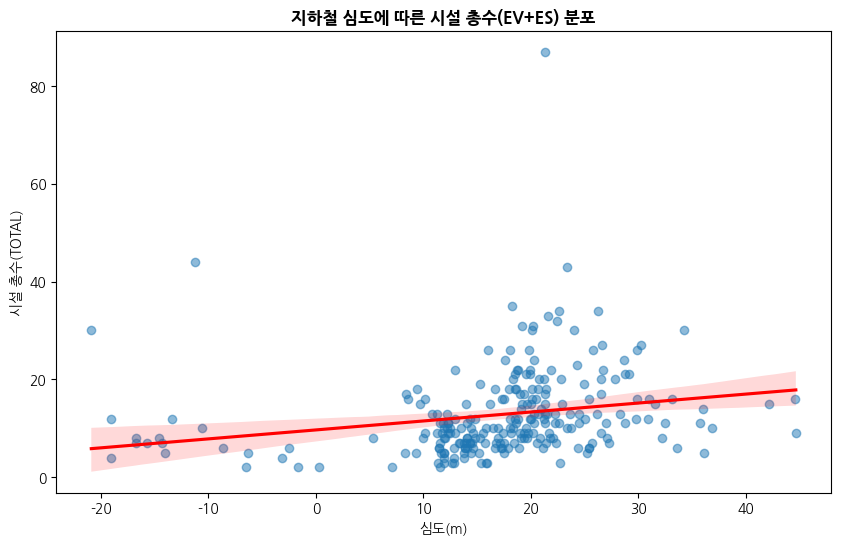

In [260]:
# 심도와 시설수의 관계를 나타낸 시각화
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_final_fixed,
    x='심도',
    y='TOTAL',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title('지하철 심도에 따른 시설 총수(EV+ES) 분포', fontweight='bold')
plt.xlabel('심도(m)')
plt.ylabel('시설 총수(TOTAL)')
plt.show()